# Evaluating Machine Learning Models for Multi-Class Hate Speech and Offensive Language Classification Using Natural Language Processing Techniques and Prototype Development

# Importing Libraries and Basic Few Operations

In [15]:
# I imported the NumPy library for performing numerical computations.
import numpy as np

# I imported the Pandas library for data loading and manipulation.
import pandas as pd

# I imported Matplotlib for creating data visualizations.
import matplotlib.pyplot as plt

# I imported Seaborn for generating statistical visualizations.
import seaborn as sns

# I configured Pandas to display all columns in the output.
pd.set_option('display.max_columns', None)

# I configured Pandas to display the complete text content within each column.
pd.set_option('display.max_colwidth', None)

# I loaded the dataset into a Pandas DataFrame.
df = pd.read_csv("labeled_data.csv")

# I displayed a heading for the first five rows.
print("First Five Rows of the Dataset")

# I displayed the first five records of the dataset.
print(df.head())

# I displayed a heading for the dataset shape.
print("\nDataset Shape")

# I displayed the number of rows and columns in the dataset.
print(df.shape)

First Five Rows of the Dataset
   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                                                                                                                          tweet  
0  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...  
1                                                         !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!  
2                      !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a 

# Data Inspection 

In [16]:
# I displayed the total number of observations in the dataset.
print("\nNumber of Observations:", df.shape[0])

# I displayed the total number of columns in the dataset.
print("Number of Columns:", df.shape[1])

# I displayed the names of all columns in the dataset.
print("\nColumn Names:")
print(df.columns.tolist())

# I displayed the target variable used for prediction.
print("\nTarget Variable:")
print("class")

# I displayed the data types of all columns.
print("\nData Types:")
print(df.dtypes)

# I displayed the total number of missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())

# I displayed the total number of duplicate records in the dataset.
print("\nDuplicate Records:")
print(df.duplicated().sum())

# I displayed the unique values present in the target variable.
print("\nUnique Values in Target Variable:")
print(df["class"].unique())


Number of Observations: 24783
Number of Columns: 7

Column Names:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Target Variable:
class

Data Types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

Missing Values:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Duplicate Records:
0

Unique Values in Target Variable:
[2 1 0]


# Data Pre-Processing & Involving NLP Processing 

In [ ]:
# I downloaded the English stopwords.
nltk.download('stopwords')


In [17]:
# I imported the required libraries for text preprocessing.
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# I displayed the total number of missing values before preprocessing.
print("Missing Values Before Preprocessing:")
print(df.isnull().sum())

# I removed the missing values from the dataset.
df = df.dropna()

# I displayed the total number of duplicate records before preprocessing.
print("\nDuplicate Records Before Preprocessing:")
print(df.duplicated().sum())

# I removed the duplicate records from the dataset.
df = df.drop_duplicates()

# I removed the unnecessary 'count' column from the dataset.
df = df.drop(columns=['count'])

# I created a list of English stopwords.
stop_words = set(stopwords.words('english'))

# I initialized the Porter Stemmer.
stemmer = PorterStemmer()

# I defined a function to preprocess the tweet text.
def preprocess_text(text):

    # I converted the text into lowercase.
    text = text.lower()

    # I removed web links from the text.
    text = re.sub(r'http\S+|www\S+', '', text)

    # I removed user mentions from the text.
    text = re.sub(r'@\w+', '', text)

    # I removed the hashtag symbol while keeping the word.
    text = re.sub(r'#', '', text)

    # I removed punctuation marks from the text.
    text = text.translate(str.maketrans('', '', string.punctuation))

    # I removed numerical values from the text.
    text = re.sub(r'\d+', '', text)

    # I removed extra white spaces from the text.
    text = re.sub(r'\s+', ' ', text).strip()

    # I removed stopwords from the text.
    words = [word for word in text.split() if word not in stop_words]

    # I applied stemming to each remaining word.
    words = [stemmer.stem(word) for word in words]

    # I joined the processed words into a single sentence.
    return " ".join(words)

# I applied the preprocessing function to the tweet text column.
df["tweet"] = df["tweet"].apply(preprocess_text)

# I displayed the first five rows after preprocessing.
print("\nFirst Five Rows After Preprocessing:")
print(df.head())

# I displayed the dataset shape after preprocessing.
print("\nDataset Shape After Preprocessing:")
print(df.shape)

# I displayed the remaining missing values after preprocessing.
print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

# I displayed the remaining duplicate records after preprocessing.
print("\nDuplicate Records After Preprocessing:")
print(df.duplicated().sum())

Missing Values Before Preprocessing:
Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

Duplicate Records Before Preprocessing:
0

First Five Rows After Preprocessing:
   Unnamed: 0  hate_speech  offensive_language  neither  class  \
0           0            0                   0        3      2   
1           1            0                   3        0      1   
2           2            0                   3        0      1   
3           3            0                   2        1      1   
4           4            0                   6        0      1   

                                                            tweet  
0  rt woman shouldnt complain clean hous amp man alway take trash  
1             rt boy dat coldtyga dwn bad cuffin dat hoe st place  
2                rt dawg rt ever fuck bitch start cri confus shit  
3                               

# Exploratory Data Analysis 

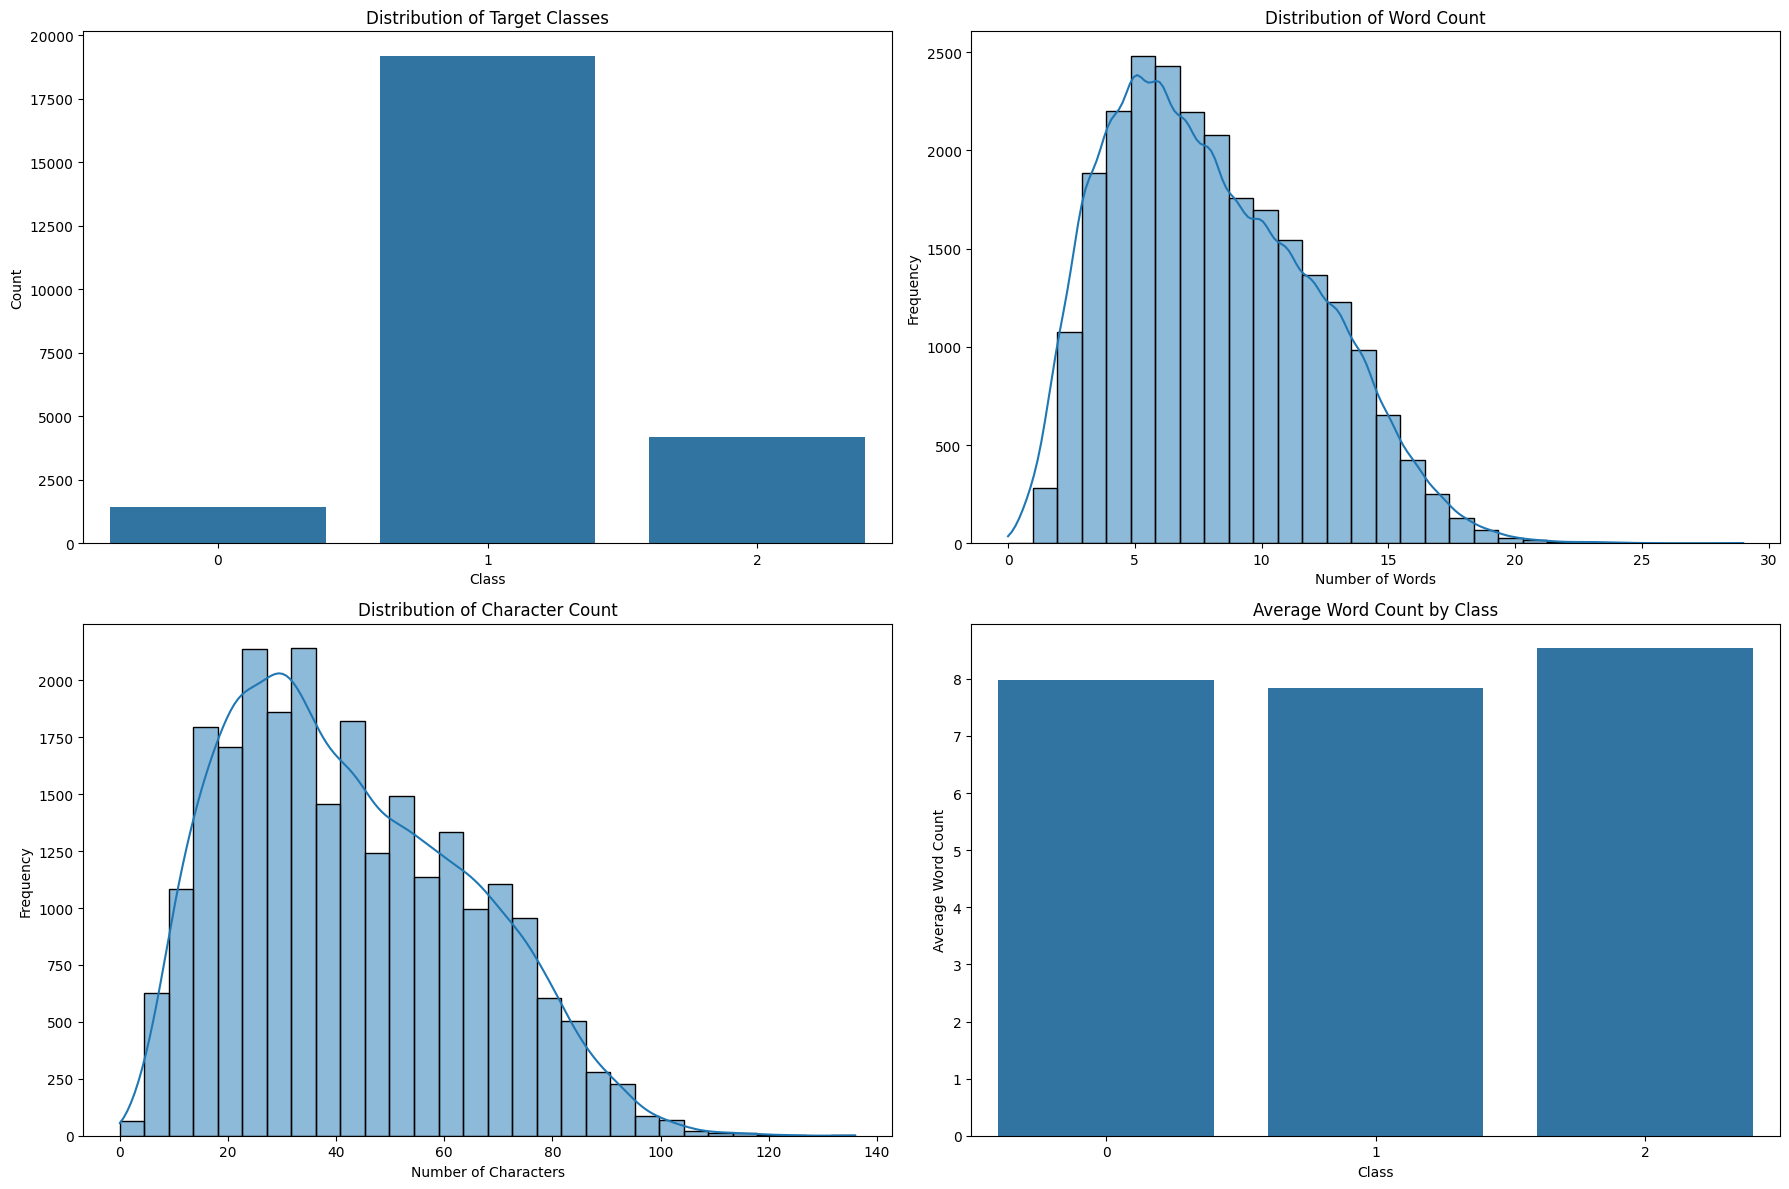

In [18]:
# I created a figure to display all exploratory data analysis plots.
plt.figure(figsize=(18,12))

# I created the plot to display the distribution of the target classes.
plt.subplot(2,2,1)
sns.countplot(data=df, x='class')
plt.title("Distribution of Target Classes")
plt.xlabel("Class")
plt.ylabel("Count")

# I calculated the number of words in each tweet.
df['Word_Count'] = df['tweet'].apply(lambda x: len(str(x).split()))

# I created the  plot to display the distribution of word counts.
plt.subplot(2,2,2)
sns.histplot(df['Word_Count'], bins=30, kde=True)
plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# I calculated the number of characters in each tweet.
df['Character_Count'] = df['tweet'].apply(len)

# I created the plot to display the distribution of character counts.
plt.subplot(2,2,3)
sns.histplot(df['Character_Count'], bins=30, kde=True)
plt.title("Distribution of Character Count")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

# I calculated the average word count for each target class.
avg_words = df.groupby('class')['Word_Count'].mean().reset_index()

# I created the plot to compare the average word count across classes.
plt.subplot(2,2,4)
sns.barplot(data=avg_words, x='class', y='Word_Count')
plt.title("Average Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Word Count")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed all the plots.
plt.show()

# Feature Extraction Using TF-IDF & BOW Techniques , Splitting the Dataset & Handling Class Imbalance Using SMOTE (Synthetic Minority Oversampling Technique)

Bag of Words Feature Matrix
Training Feature Matrix Shape: (19826, 5000)
Testing Feature Matrix Shape: (4957, 5000)
Total Number of Features: 5000

First 20 Bag of Words Features:
['aa' 'aap' 'aaron' 'ab' 'abil' 'abl' 'abo' 'abort' 'absolut' 'abt' 'abu'
 'abus' 'ac' 'accent' 'accept' 'accid' 'accident' 'accord' 'account'
 'accur']

TF-IDF Feature Matrix
Training Feature Matrix Shape: (19826, 5000)
Testing Feature Matrix Shape: (4957, 5000)
Total Number of Features: 5000

First 20 TF-IDF Features:
['aa' 'aap' 'aaron' 'ab' 'abil' 'abl' 'abo' 'abort' 'absolut' 'abt' 'abu'
 'abus' 'ac' 'accent' 'accept' 'accid' 'accident' 'accord' 'account'
 'accur']

Training Class Distribution:
class
1    15352
2     3330
0     1144
Name: count, dtype: int64

Testing Class Distribution:
class
1    3838
2     833
0     286
Name: count, dtype: int64

Bag of Words After SMOTE
Training Feature Shape Before SMOTE: (19826, 5000)
Training Target Shape Before SMOTE: (19826,)
Training Feature Shape After SMOTE: (

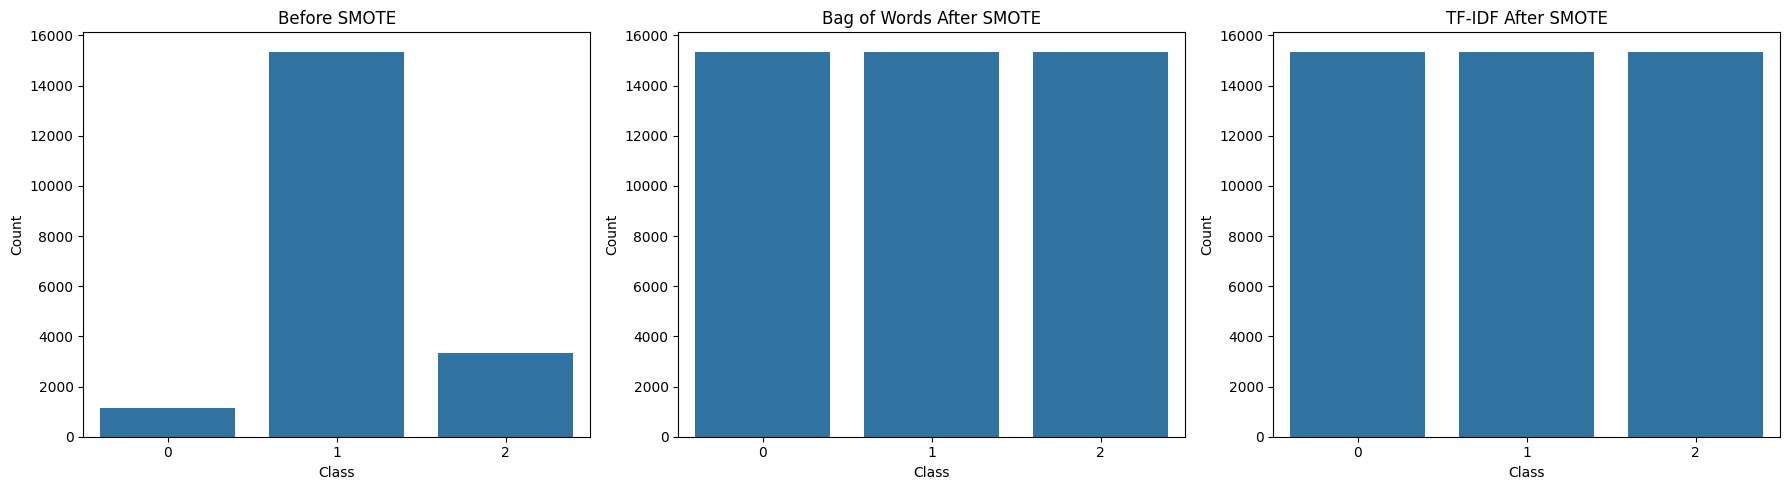

In [6]:
# I imported the required libraries.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# I selected the tweet column as the input feature.
X = df["tweet"]

# I selected the class column as the target variable.
y = df["class"]

# I split the dataset into training and testing sets.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# I initialized the Bag of Words vectorizer.
bow = CountVectorizer(max_features=5000)

# I fitted the Bag of Words vectorizer on the training data.
X_train_bow = bow.fit_transform(X_train_text)

# I transformed the testing data using the fitted Bag of Words vectorizer.
X_test_bow = bow.transform(X_test_text)

# I initialized the TF-IDF vectorizer.
tfidf = TfidfVectorizer(max_features=5000)

# I fitted the TF-IDF vectorizer on the training data.
X_train_tfidf = tfidf.fit_transform(X_train_text)

# I transformed the testing data using the fitted TF-IDF vectorizer.
X_test_tfidf = tfidf.transform(X_test_text)

# I displayed the Bag of Words feature matrix information.
print("Bag of Words Feature Matrix")
print("Training Feature Matrix Shape:", X_train_bow.shape)
print("Testing Feature Matrix Shape:", X_test_bow.shape)
print("Total Number of Features:", len(bow.get_feature_names_out()))

print("\nFirst 20 Bag of Words Features:")
print(bow.get_feature_names_out()[:20])

# I displayed the TF-IDF feature matrix information.
print("\nTF-IDF Feature Matrix")
print("Training Feature Matrix Shape:", X_train_tfidf.shape)
print("Testing Feature Matrix Shape:", X_test_tfidf.shape)
print("Total Number of Features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 TF-IDF Features:")
print(tfidf.get_feature_names_out()[:20])

# I displayed the class distributions.
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

# I initialized the SMOTE technique.
smote = SMOTE(random_state=42)

# I applied SMOTE to the Bag of Words training data.
X_train_bow_smote, y_train_bow_smote = smote.fit_resample(
    X_train_bow,
    y_train
)

# I applied SMOTE to the TF-IDF training data.
X_train_tfidf_smote, y_train_tfidf_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

# I displayed the Bag of Words dataset after applying SMOTE.
print("\nBag of Words After SMOTE")
print("Training Feature Shape Before SMOTE:", X_train_bow.shape)
print("Training Target Shape Before SMOTE:", y_train.shape)
print("Training Feature Shape After SMOTE:", X_train_bow_smote.shape)
print("Training Target Shape After SMOTE:", y_train_bow_smote.shape)

print("\nClass Distribution After SMOTE (Bag of Words):")
print(y_train_bow_smote.value_counts())

# I displayed the TF-IDF dataset after applying SMOTE.
print("\nTF-IDF After SMOTE")
print("Training Feature Shape Before SMOTE:", X_train_tfidf.shape)
print("Training Target Shape Before SMOTE:", y_train.shape)
print("Training Feature Shape After SMOTE:", X_train_tfidf_smote.shape)
print("Training Target Shape After SMOTE:", y_train_tfidf_smote.shape)

print("\nClass Distribution After SMOTE (TF-IDF):")
print(y_train_tfidf_smote.value_counts())

# I created a figure to compare the class distributions.
plt.figure(figsize=(18,5))

# I plotted the class distribution before applying SMOTE.
plt.subplot(1,3,1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I plotted the class distribution after applying SMOTE to the Bag of Words dataset.
plt.subplot(1,3,2)
sns.countplot(x=y_train_bow_smote)
plt.title("Bag of Words After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I plotted the class distribution after applying SMOTE to the TF-IDF dataset.
plt.subplot(1,3,3)
sns.countplot(x=y_train_tfidf_smote)
plt.title("TF-IDF After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

# I adjusted the spacing between the plots.
plt.tight_layout()

# I displayed the plots.
plt.show()

# Training & Evaluating the Models 

# Technique 1 : Term Frequency - Inverse Document Frequency (TF-IDF)

# Logistic Regression (TF-IDF)

In [8]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression model.
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# I trained the Logistic Regression model.
lr_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

# I predicted the class probabilities.
y_prob_tfidf = lr_tfidf.predict_proba(X_test_tfidf)

# I calculated the evaluation metrics.
lr_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_tfidf
)

lr_tfidf_precision = precision_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_recall = recall_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_f1_score = f1_score(
    y_test,
    y_pred_tfidf,
    average="weighted"
)

lr_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLogistic Regression Performance")

print(f"Accuracy      : {lr_tfidf_accuracy:.4f}")
print(f"Precision     : {lr_tfidf_precision:.4f}")
print(f"Recall        : {lr_tfidf_recall:.4f}")
print(f"F1-Score      : {lr_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {lr_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")

print(classification_report(y_test, y_pred_tfidf))


Logistic Regression Performance
Accuracy      : 0.8477
Precision     : 0.8918
Recall        : 0.8477
F1-Score      : 0.8637
ROC-AUC Score : 0.9301

Classification Report
              precision    recall  f1-score   support

           0       0.29      0.58      0.38       286
           1       0.96      0.85      0.90      3838
           2       0.79      0.92      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.78      0.71      4957
weighted avg       0.89      0.85      0.86      4957



# Technique 2 : Bag Of Words (BoW)

# Logistic Regression (BoW) 

In [9]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Logistic Regression model.
lr_bow = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# I trained the Logistic Regression model.
lr_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_bow = lr_bow.predict(X_test_bow)

# I predicted the class probabilities.
y_prob_bow = lr_bow.predict_proba(X_test_bow)

# I calculated the evaluation metrics.
lr_bow_accuracy = accuracy_score(
    y_test,
    y_pred_bow
)

lr_bow_precision = precision_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_recall = recall_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_f1_score = f1_score(
    y_test,
    y_pred_bow,
    average="weighted"
)

lr_bow_auc = roc_auc_score(
    y_test,
    y_prob_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLogistic Regression Performance (Bag of Words)")
print(f"Accuracy      : {lr_bow_accuracy:.4f}")
print(f"Precision     : {lr_bow_precision:.4f}")
print(f"Recall        : {lr_bow_recall:.4f}")
print(f"F1-Score      : {lr_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {lr_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_bow))


Logistic Regression Performance (Bag of Words)
Accuracy      : 0.8521
Precision     : 0.8787
Recall        : 0.8521
F1-Score      : 0.8635
ROC-AUC Score : 0.8989

Classification Report
              precision    recall  f1-score   support

           0       0.26      0.43      0.32       286
           1       0.93      0.88      0.91      3838
           2       0.83      0.87      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.73      0.69      4957
weighted avg       0.88      0.85      0.86      4957



# LightGBM (TF-IDF)

In [ ]:
!pip install lightgbm

In [10]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the LightGBM model.
lightgbm_tfidf = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I trained the LightGBM model.
lightgbm_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_lightgbm_tfidf = lightgbm_tfidf.predict(X_test_tfidf)

# I predicted the class probabilities.
y_prob_lightgbm_tfidf = lightgbm_tfidf.predict_proba(X_test_tfidf)

# I calculated the evaluation metrics.
lightgbm_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_lightgbm_tfidf
)

lightgbm_tfidf_precision = precision_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_recall = recall_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_f1_score = f1_score(
    y_test,
    y_pred_lightgbm_tfidf,
    average="weighted"
)

lightgbm_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_lightgbm_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLightGBM Performance")

print(f"Accuracy      : {lightgbm_tfidf_accuracy:.4f}")
print(f"Precision     : {lightgbm_tfidf_precision:.4f}")
print(f"Recall        : {lightgbm_tfidf_recall:.4f}")
print(f"F1-Score      : {lightgbm_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {lightgbm_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_lightgbm_tfidf))


LightGBM Performance
Accuracy      : 0.8838
Precision     : 0.9024
Recall        : 0.8838
F1-Score      : 0.8907
ROC-AUC Score : 0.9477

Classification Report
              precision    recall  f1-score   support

           0       0.37      0.53      0.44       286
           1       0.96      0.90      0.93      3838
           2       0.82      0.94      0.87       833

    accuracy                           0.88      4957
   macro avg       0.72      0.79      0.75      4957
weighted avg       0.90      0.88      0.89      4957



# LightGBM (BoW)

In [11]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the feature matrices to float32.
X_train_bow_smote = X_train_bow_smote.astype("float32")
X_test_bow = X_test_bow.astype("float32")

# I initialized the LightGBM model.
lightgbm_bow = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I trained the LightGBM model.
lightgbm_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_lightgbm_bow = lightgbm_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_lightgbm_bow = lightgbm_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
lightgbm_bow_accuracy = accuracy_score(
    y_test,
    y_pred_lightgbm_bow
)

lightgbm_bow_precision = precision_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_recall = recall_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_f1_score = f1_score(
    y_test,
    y_pred_lightgbm_bow,
    average="weighted"
)

lightgbm_bow_auc = roc_auc_score(
    y_test,
    y_prob_lightgbm_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nLightGBM Performance (Bag of Words)")

print(f"Accuracy      : {lightgbm_bow_accuracy:.4f}")
print(f"Precision     : {lightgbm_bow_precision:.4f}")
print(f"Recall        : {lightgbm_bow_recall:.4f}")
print(f"F1-Score      : {lightgbm_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {lightgbm_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_lightgbm_bow))


LightGBM Performance (Bag of Words)
Accuracy      : 0.8759
Precision     : 0.8880
Recall        : 0.8759
F1-Score      : 0.8810
ROC-AUC Score : 0.9170

Classification Report
              precision    recall  f1-score   support

           0       0.33      0.42      0.37       286
           1       0.94      0.90      0.92      3838
           2       0.82      0.91      0.86       833

    accuracy                           0.88      4957
   macro avg       0.70      0.74      0.72      4957
weighted avg       0.89      0.88      0.88      4957



# Decision Tree(TF-IDF)

In [12]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Decision Tree model.
decision_tree_tfidf = DecisionTreeClassifier(
    random_state=42
)

# I trained the Decision Tree model.
decision_tree_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_decision_tree_tfidf = decision_tree_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_decision_tree_tfidf = decision_tree_tfidf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
decision_tree_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_tfidf
)

decision_tree_tfidf_precision = precision_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_recall = recall_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_f1_score = f1_score(
    y_test,
    y_pred_decision_tree_tfidf,
    average="weighted"
)

decision_tree_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_decision_tree_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nDecision Tree Performance (TF-IDF)")

print(f"Accuracy      : {decision_tree_tfidf_accuracy:.4f}")
print(f"Precision     : {decision_tree_tfidf_precision:.4f}")
print(f"Recall        : {decision_tree_tfidf_recall:.4f}")
print(f"F1-Score      : {decision_tree_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {decision_tree_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_decision_tree_tfidf))


Decision Tree Performance (TF-IDF)
Accuracy      : 0.8683
Precision     : 0.8850
Recall        : 0.8683
F1-Score      : 0.8755
ROC-AUC Score : 0.8521

Classification Report
              precision    recall  f1-score   support

           0       0.32      0.47      0.38       286
           1       0.94      0.90      0.92      3838
           2       0.83      0.85      0.84       833

    accuracy                           0.87      4957
   macro avg       0.70      0.74      0.71      4957
weighted avg       0.88      0.87      0.88      4957



# Decision Tree (BoW)

In [9]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Decision Tree model.
decision_tree_bow = DecisionTreeClassifier(
    random_state=42
)

# I trained the Decision Tree model.
decision_tree_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_decision_tree_bow = decision_tree_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_decision_tree_bow = decision_tree_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
decision_tree_bow_accuracy = accuracy_score(
    y_test,
    y_pred_decision_tree_bow
)

decision_tree_bow_precision = precision_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_recall = recall_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_f1_score = f1_score(
    y_test,
    y_pred_decision_tree_bow,
    average="weighted"
)

decision_tree_bow_auc = roc_auc_score(
    y_test,
    y_prob_decision_tree_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nDecision Tree Performance (Bag of Words)")

print(f"Accuracy      : {decision_tree_bow_accuracy:.4f}")
print(f"Precision     : {decision_tree_bow_precision:.4f}")
print(f"Recall        : {decision_tree_bow_recall:.4f}")
print(f"F1-Score      : {decision_tree_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {decision_tree_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_decision_tree_bow))


Decision Tree Performance (Bag of Words)
Accuracy      : 0.7527
Precision     : 0.8669
Recall        : 0.7527
F1-Score      : 0.7974
ROC-AUC Score : 0.8381

Classification Report
              precision    recall  f1-score   support

           0       0.14      0.48      0.21       286
           1       0.93      0.76      0.84      3838
           2       0.80      0.81      0.81       833

    accuracy                           0.75      4957
   macro avg       0.63      0.68      0.62      4957
weighted avg       0.87      0.75      0.80      4957



# Multinominal Naive Bayes (TF-IDF)

In [12]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_tfidf = MultinomialNB()

# I trained the Multinomial Naïve Bayes model.
naive_bayes_tfidf.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I predicted the testing labels.
y_pred_naive_bayes_tfidf = naive_bayes_tfidf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_naive_bayes_tfidf = naive_bayes_tfidf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
naive_bayes_tfidf_accuracy = accuracy_score(
    y_test,
    y_pred_naive_bayes_tfidf
)

naive_bayes_tfidf_precision = precision_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_recall = recall_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_f1_score = f1_score(
    y_test,
    y_pred_naive_bayes_tfidf,
    average="weighted"
)

naive_bayes_tfidf_auc = roc_auc_score(
    y_test,
    y_prob_naive_bayes_tfidf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nMultinomial Naïve Bayes Performance (TF-IDF)")

print(f"Accuracy      : {naive_bayes_tfidf_accuracy:.4f}")
print(f"Precision     : {naive_bayes_tfidf_precision:.4f}")
print(f"Recall        : {naive_bayes_tfidf_recall:.4f}")
print(f"F1-Score      : {naive_bayes_tfidf_f1_score:.4f}")
print(f"ROC-AUC Score : {naive_bayes_tfidf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_naive_bayes_tfidf))


Multinomial Naïve Bayes Performance (TF-IDF)
Accuracy      : 0.8104
Precision     : 0.8647
Recall        : 0.8104
F1-Score      : 0.8315
ROC-AUC Score : 0.8992

Classification Report
              precision    recall  f1-score   support

           0       0.24      0.55      0.33       286
           1       0.94      0.83      0.88      3838
           2       0.75      0.80      0.78       833

    accuracy                           0.81      4957
   macro avg       0.64      0.73      0.66      4957
weighted avg       0.86      0.81      0.83      4957



# Multinominal Naive Bayes (BoW)

In [13]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_bow = MultinomialNB()

# I trained the Multinomial Naïve Bayes model.
naive_bayes_bow.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I predicted the testing labels.
y_pred_naive_bayes_bow = naive_bayes_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_naive_bayes_bow = naive_bayes_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
naive_bayes_bow_accuracy = accuracy_score(
    y_test,
    y_pred_naive_bayes_bow
)

naive_bayes_bow_precision = precision_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_recall = recall_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_f1_score = f1_score(
    y_test,
    y_pred_naive_bayes_bow,
    average="weighted"
)

naive_bayes_bow_auc = roc_auc_score(
    y_test,
    y_prob_naive_bayes_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nMultinomial Naïve Bayes Performance (Bag of Words)")

print(f"Accuracy      : {naive_bayes_bow_accuracy:.4f}")
print(f"Precision     : {naive_bayes_bow_precision:.4f}")
print(f"Recall        : {naive_bayes_bow_recall:.4f}")
print(f"F1-Score      : {naive_bayes_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {naive_bayes_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_naive_bayes_bow))


Multinomial Naïve Bayes Performance (Bag of Words)
Accuracy      : 0.8566
Precision     : 0.8778
Recall        : 0.8566
F1-Score      : 0.8657
ROC-AUC Score : 0.8993

Classification Report
              precision    recall  f1-score   support

           0       0.30      0.48      0.37       286
           1       0.93      0.89      0.91      3838
           2       0.83      0.83      0.83       833

    accuracy                           0.86      4957
   macro avg       0.69      0.73      0.70      4957
weighted avg       0.88      0.86      0.87      4957



# Combined Comparative Table and Bar Graph for all Default Models 


Bag of Words Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.852128,0.878720,0.852128,0.863494,0.898932
1,LightGBM,0.875933,0.888010,0.875933,0.880972,0.916955
2,Decision Tree,0.752673,0.866907,0.752673,0.797415,0.838145
3,Naïve Bayes,0.856566,0.877771,0.856566,0.865655,0.899253


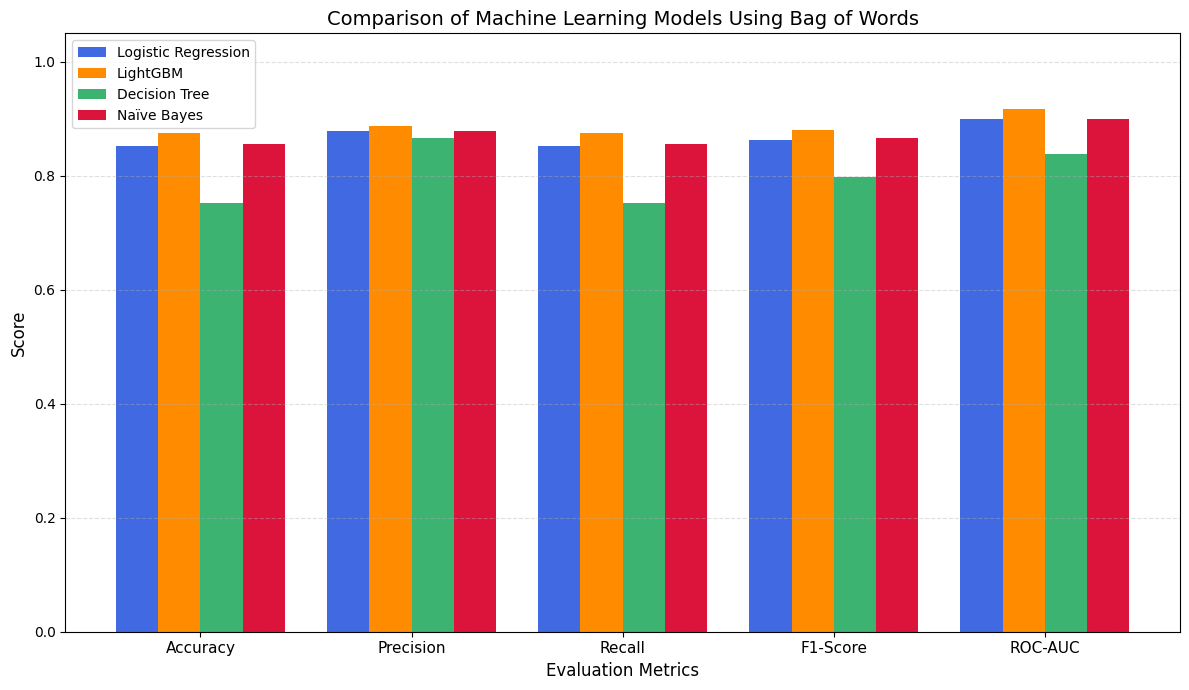

In [14]:
# I imported the required libraries.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# I created the comparison table.
comparison_results_bow = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "Decision Tree",
        "Naïve Bayes"
    ],
    "Accuracy": [
        lr_bow_accuracy,
        lightgbm_bow_accuracy,
        decision_tree_bow_accuracy,
        naive_bayes_bow_accuracy
    ],
    "Precision": [
        lr_bow_precision,
        lightgbm_bow_precision,
        decision_tree_bow_precision,
        naive_bayes_bow_precision
    ],
    "Recall": [
        lr_bow_recall,
        lightgbm_bow_recall,
        decision_tree_bow_recall,
        naive_bayes_bow_recall
    ],
    "F1-Score": [
        lr_bow_f1_score,
        lightgbm_bow_f1_score,
        decision_tree_bow_f1_score,
        naive_bayes_bow_f1_score
    ],
    "ROC-AUC": [
        lr_bow_auc,
        lightgbm_bow_auc,
        decision_tree_bow_auc,
        naive_bayes_bow_auc
    ]
})

# I displayed the comparison table.
print("\nBag of Words Model Comparison")
display(comparison_results_bow)

# I created a grouped bar chart.
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12,7))

plt.bar(
    x - 1.5*width,
    comparison_results_bow.loc[0, metrics],
    width,
    label="Logistic Regression",
    color="royalblue"
)

plt.bar(
    x - 0.5*width,
    comparison_results_bow.loc[1, metrics],
    width,
    label="LightGBM",
    color="darkorange"
)

plt.bar(
    x + 0.5*width,
    comparison_results_bow.loc[2, metrics],
    width,
    label="Decision Tree",
    color="mediumseagreen"
)

plt.bar(
    x + 1.5*width,
    comparison_results_bow.loc[3, metrics],
    width,
    label="Naïve Bayes",
    color="crimson"
)

plt.xticks(x, metrics, fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)
plt.title("Comparison of Machine Learning Models Using Bag of Words", fontsize=14)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

# Visual Analysis for each metric : Default Models 

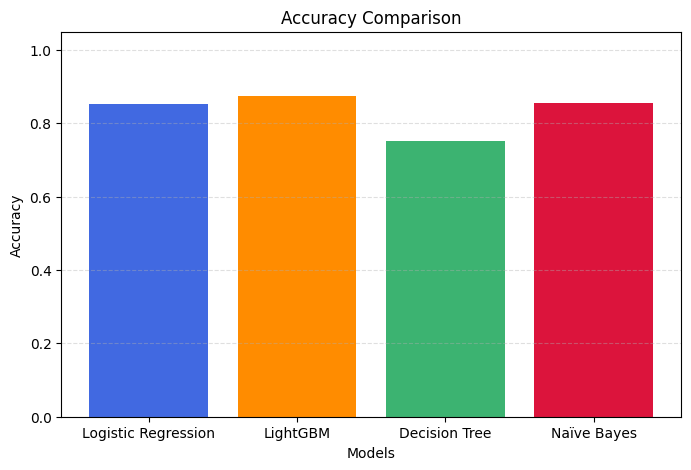

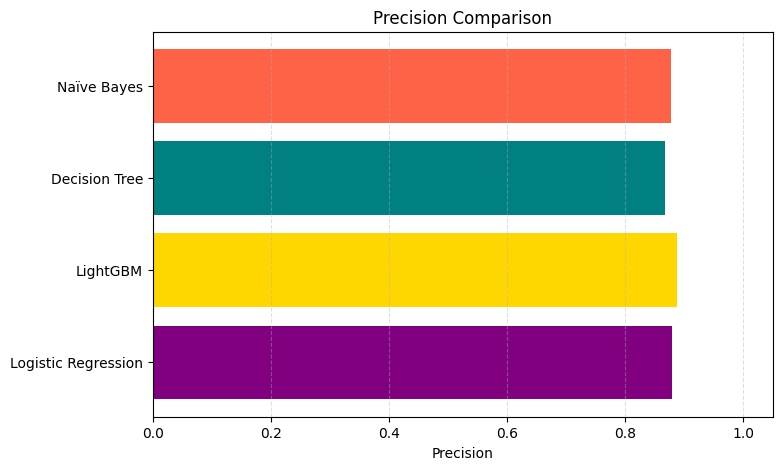

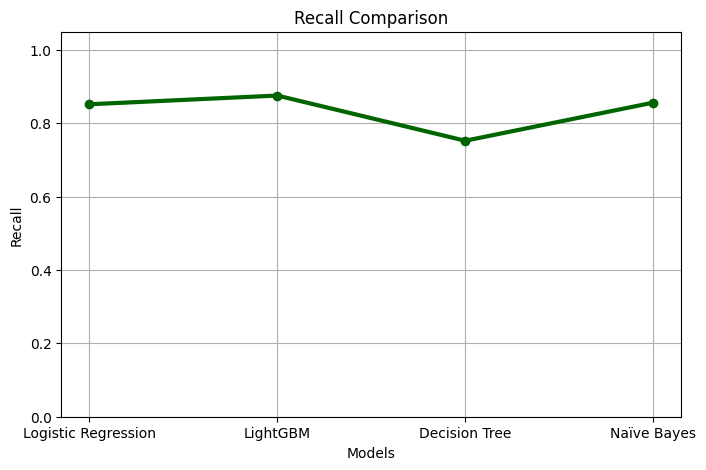

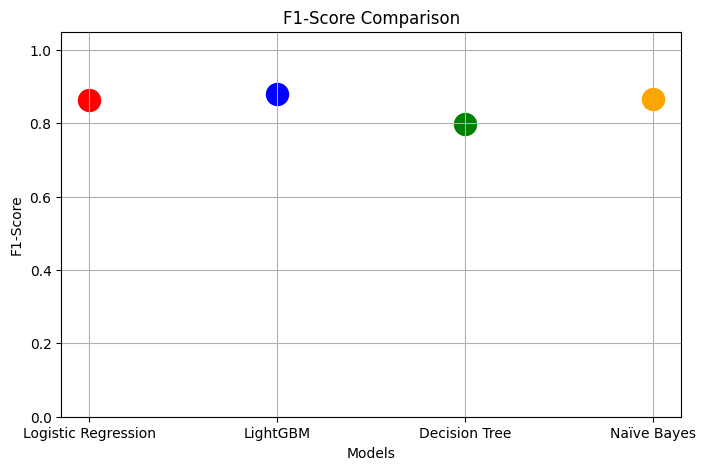

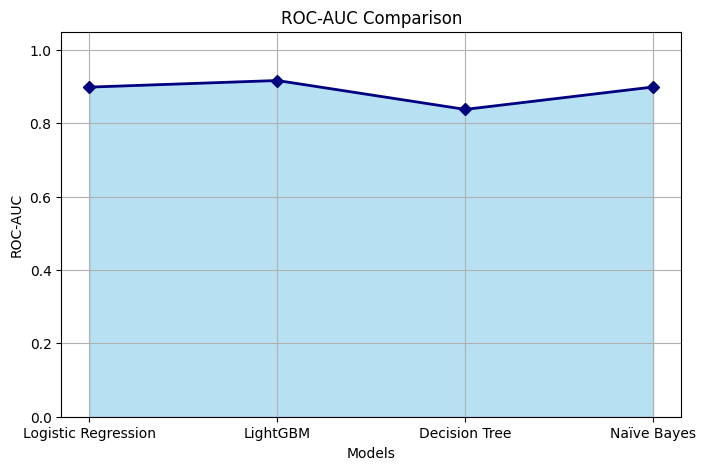

In [15]:
# I imported the required libraries.
import matplotlib.pyplot as plt

models = comparison_results_bow["Model"]

# Accuracy - Bar Chart
plt.figure(figsize=(8,5))
plt.bar(
    models,
    comparison_results_bow["Accuracy"],
    color=["royalblue", "darkorange", "mediumseagreen", "crimson"]
)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


# Precision - Horizontal Bar Chart
plt.figure(figsize=(8,5))
plt.barh(
    models,
    comparison_results_bow["Precision"],
    color=["purple", "gold", "teal", "tomato"]
)
plt.title("Precision Comparison")
plt.xlabel("Precision")
plt.xlim(0,1.05)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()


# Recall - Line Chart
plt.figure(figsize=(8,5))
plt.plot(
    models,
    comparison_results_bow["Recall"],
    marker="o",
    linewidth=3,
    color="darkgreen"
)
plt.title("Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()


# F1-Score - Scatter Plot
plt.figure(figsize=(8,5))

colors = ["red", "blue", "green", "orange"]

for i, model in enumerate(models):
    plt.scatter(
        model,
        comparison_results_bow["F1-Score"][i],
        s=250,
        color=colors[i]
    )

plt.title("F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-Score")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()


# ROC-AUC - Area Chart
plt.figure(figsize=(8,5))
plt.fill_between(
    models,
    comparison_results_bow["ROC-AUC"],
    color="skyblue",
    alpha=0.6
)
plt.plot(
    models,
    comparison_results_bow["ROC-AUC"],
    marker="D",
    linewidth=2,
    color="navy"
)
plt.title("ROC-AUC Comparison")
plt.xlabel("Models")
plt.ylabel("ROC-AUC")
plt.ylim(0,1.05)
plt.grid(True)
plt.show()

# Combined AUC-ROC Curve for Default Models (TF-IDF)

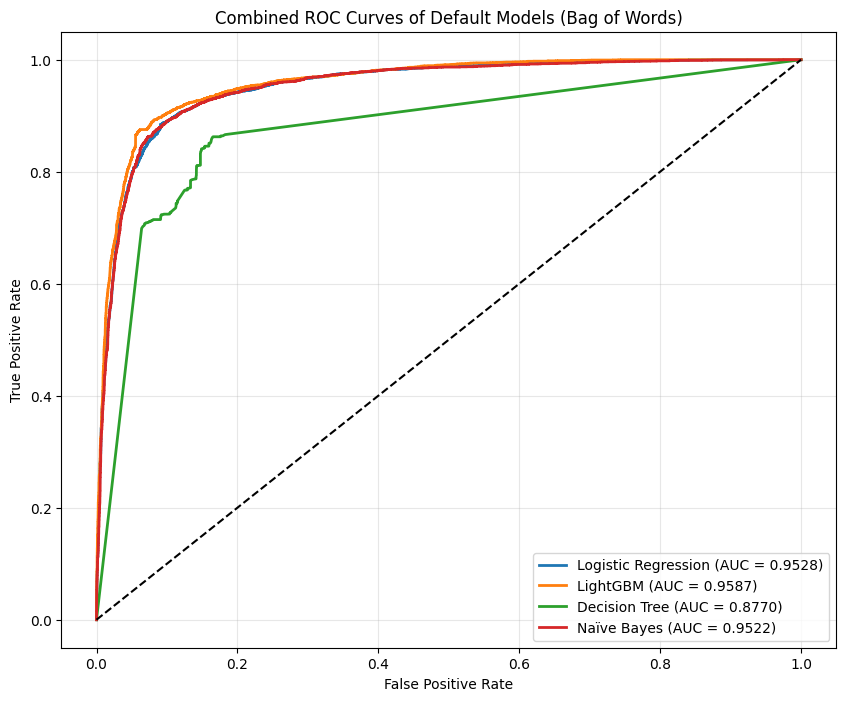

In [16]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels to binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I created a dictionary containing the models.
models = {
    "Logistic Regression": y_prob_bow,
    "LightGBM": y_prob_lightgbm_bow,
    "Decision Tree": y_prob_decision_tree_bow,
    "Naïve Bayes": y_prob_naive_bayes_bow
}

# I created the ROC curve figure.
plt.figure(figsize=(10,8))

# I plotted the micro-average ROC curve for each model.
for model_name, y_prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier line.
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

# I customized the figure.
plt.title("Combined ROC Curves of Default Models (Bag of Words)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

# Combined AUC-ROC Curve for Default Models (BoW)

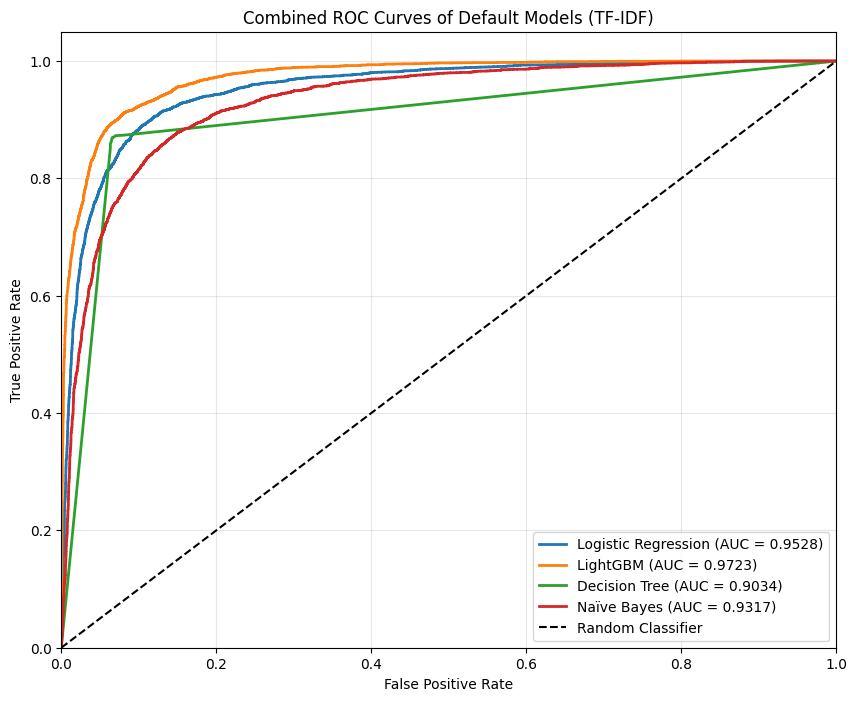

In [17]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels to binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I created a dictionary containing the predicted probabilities.
models = {
    "Logistic Regression": y_prob_tfidf,
    "LightGBM": y_prob_lightgbm_tfidf,
    "Decision Tree": y_prob_decision_tree_tfidf,
    "Naïve Bayes": y_prob_naive_bayes_tfidf
}

# I created the ROC curve figure.
plt.figure(figsize=(10, 8))

# I plotted the ROC curve for each model.
for model_name, y_prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

# I customized the figure.
plt.title("Combined ROC Curves of Default Models (TF-IDF)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

# Combined AUC-ROC Curve for Default Models (TF-IDF & BoW)

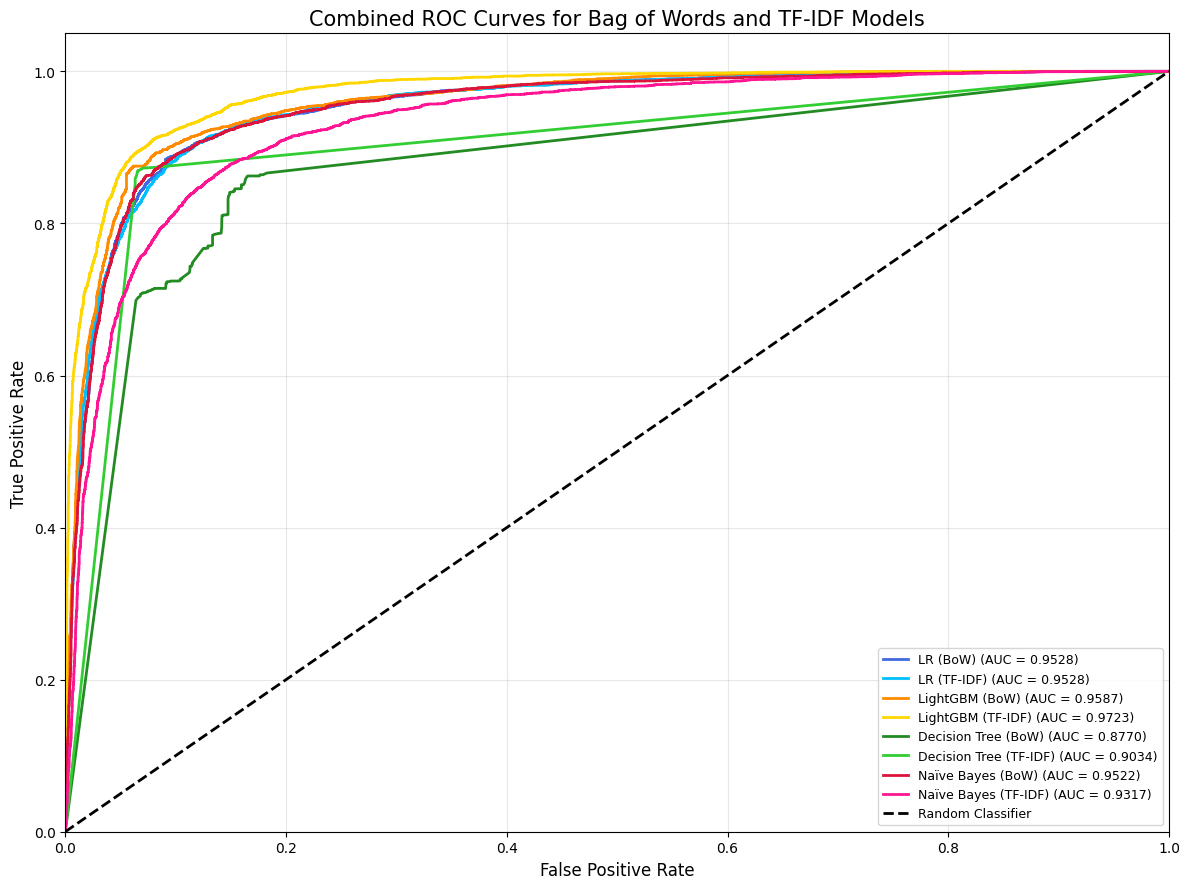

In [18]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I converted the test labels into binary format.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

# I stored the predicted probabilities.
models = {
    "LR (BoW)": y_prob_bow,
    "LR (TF-IDF)": y_prob_tfidf,
    "LightGBM (BoW)": y_prob_lightgbm_bow,
    "LightGBM (TF-IDF)": y_prob_lightgbm_tfidf,
    "Decision Tree (BoW)": y_prob_decision_tree_bow,
    "Decision Tree (TF-IDF)": y_prob_decision_tree_tfidf,
    "Naïve Bayes (BoW)": y_prob_naive_bayes_bow,
    "Naïve Bayes (TF-IDF)": y_prob_naive_bayes_tfidf
}

# I created the figure.
plt.figure(figsize=(12,9))

colors = [
    "royalblue",
    "deepskyblue",
    "darkorange",
    "gold",
    "forestgreen",
    "limegreen",
    "crimson",
    "deeppink"
]

# I plotted the ROC curve for each model.
for (model_name, y_prob), color in zip(models.items(), colors):

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc:.4f})"
    )

# I plotted the random classifier.
plt.plot(
    [0,1],
    [0,1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# I customized the plot.
plt.title(
    "Combined ROC Curves for Bag of Words and TF-IDF Models",
    fontsize=15
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.xlim(0,1)
plt.ylim(0,1.05)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

plt.show()

# Hyper Parameter Tuning  for all Default Models

# Tuned Logistic Regression (TF-IDF)

In [19]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
lr_param_grid = {
    "C": [0.1, 1, 10]
}

# I initialized the Logistic Regression model.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I initialized GridSearchCV.
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_lr.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_lr.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_lr.best_score_:.4f}")

# I stored the best model.
tuned_lr_tf_idf = grid_lr.best_estimator_

# I predicted the testing labels.
y_pred_tuned_lr_tf_idf = tuned_lr_tf_idf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_tuned_lr_tf_idf = tuned_lr_tf_idf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
tuned_lr_tf_idf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr_tf_idf
)

tuned_lr_tf_idf_precision = precision_score(
    y_test,
    y_pred_tuned_lr_tf_idf,
    average="weighted"
)

tuned_lr_tf_idf_recall = recall_score(
    y_test,
    y_pred_tuned_lr_tf_idf,
    average="weighted"
)

tuned_lr_tf_idf_f1_score = f1_score(
    y_test,
    y_pred_tuned_lr_tf_idf,
    average="weighted"
)

tuned_lr_tf_idf_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lr_tf_idf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Logistic Regression Performance")

print(f"Accuracy      : {tuned_lr_tf_idf_accuracy:.4f}")
print(f"Precision     : {tuned_lr_tf_idf_precision:.4f}")
print(f"Recall        : {tuned_lr_tf_idf_recall:.4f}")
print(f"F1-Score      : {tuned_lr_tf_idf_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_lr_tf_idf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_lr_tf_idf))


Best Parameters
{'C': 10}

Best Cross Validation Accuracy
0.9235

Optimized Logistic Regression Performance
Accuracy      : 0.8386
Precision     : 0.8784
Recall        : 0.8386
F1-Score      : 0.8547
ROC-AUC Score : 0.9131

Classification Report
              precision    recall  f1-score   support

           0       0.25      0.49      0.33       286
           1       0.94      0.86      0.90      3838
           2       0.82      0.86      0.84       833

    accuracy                           0.84      4957
   macro avg       0.67      0.74      0.69      4957
weighted avg       0.88      0.84      0.85      4957



# Tuned Logistic Regression (BoW)

In [20]:
# I imported the required libraries.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
lr_param_grid = {
    "C": [0.1, 1, 10]
}

# I initialized the Logistic Regression model.
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# I initialized GridSearchCV.
grid_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_lr.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_lr.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_lr.best_score_:.4f}")

# I stored the best model.
tuned_lr_bow = grid_lr.best_estimator_

# I predicted the testing labels.
y_pred_tuned_lr_bow = tuned_lr_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_tuned_lr_bow = tuned_lr_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
tuned_lr_bow_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lr_bow
)

tuned_lr_bow_precision = precision_score(
    y_test,
    y_pred_tuned_lr_bow,
    average="weighted"
)

tuned_lr_bow_recall = recall_score(
    y_test,
    y_pred_tuned_lr_bow,
    average="weighted"
)

tuned_lr_bow_f1_score = f1_score(
    y_test,
    y_pred_tuned_lr_bow,
    average="weighted"
)

tuned_lr_bow_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lr_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Logistic Regression Performance (Bag of Words)")

print(f"Accuracy      : {tuned_lr_bow_accuracy:.4f}")
print(f"Precision     : {tuned_lr_bow_precision:.4f}")
print(f"Recall        : {tuned_lr_bow_recall:.4f}")
print(f"F1-Score      : {tuned_lr_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_lr_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_lr_bow))


Best Parameters
{'C': 1}

Best Cross Validation Accuracy
0.8382

Optimized Logistic Regression Performance (Bag of Words)
Accuracy      : 0.8521
Precision     : 0.8787
Recall        : 0.8521
F1-Score      : 0.8635
ROC-AUC Score : 0.8989

Classification Report
              precision    recall  f1-score   support

           0       0.26      0.43      0.32       286
           1       0.93      0.88      0.91      3838
           2       0.83      0.87      0.85       833

    accuracy                           0.85      4957
   macro avg       0.68      0.73      0.69      4957
weighted avg       0.88      0.85      0.86      4957



# Tuned LightGBM(TF-IDF)

In [13]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
lightgbm_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

# I initialized the LightGBM model.
lightgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I initialized GridSearchCV.
grid_lightgbm = GridSearchCV(
    estimator=lightgbm_model,
    param_grid=lightgbm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_lightgbm.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_lightgbm.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_lightgbm.best_score_:.4f}")

# I stored the best model.
tuned_lightgbm_tf_idf = grid_lightgbm.best_estimator_

# I predicted the testing labels.
y_pred_tuned_lightgbm_tf_idf = tuned_lightgbm_tf_idf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_tuned_lightgbm_tf_idf = tuned_lightgbm_tf_idf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
tuned_lightgbm_tf_idf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lightgbm_tf_idf
)

tuned_lightgbm_tf_idf_precision = precision_score(
    y_test,
    y_pred_tuned_lightgbm_tf_idf,
    average="weighted"
)

tuned_lightgbm_tf_idf_recall = recall_score(
    y_test,
    y_pred_tuned_lightgbm_tf_idf,
    average="weighted"
)

tuned_lightgbm_tf_idf_f1_score = f1_score(
    y_test,
    y_pred_tuned_lightgbm_tf_idf,
    average="weighted"
)

tuned_lightgbm_tf_idf_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lightgbm_tf_idf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized LightGBM Performance")

print(f"Accuracy      : {tuned_lightgbm_tf_idf_accuracy:.4f}")
print(f"Precision     : {tuned_lightgbm_tf_idf_precision:.4f}")
print(f"Recall        : {tuned_lightgbm_tf_idf_recall:.4f}")
print(f"F1-Score      : {tuned_lightgbm_tf_idf_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_lightgbm_tf_idf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_lightgbm_tf_idf))


Best Parameters
{'learning_rate': 0.1, 'n_estimators': 200}

Best Cross Validation Accuracy
0.9445

Optimized LightGBM Performance
Accuracy      : 0.8897
Precision     : 0.8988
Recall        : 0.8897
F1-Score      : 0.8931
ROC-AUC Score : 0.9449

Classification Report
              precision    recall  f1-score   support

           0       0.40      0.48      0.44       286
           1       0.95      0.91      0.93      3838
           2       0.82      0.93      0.87       833

    accuracy                           0.89      4957
   macro avg       0.72      0.77      0.75      4957
weighted avg       0.90      0.89      0.89      4957



In [14]:
import joblib

# Saved the correct tuned TF-IDF LightGBM model
best_lightgbm_model = tuned_lightgbm_tf_idf

joblib.dump(best_lightgbm_model, "multi_best_lightgbm_model.pkl")
joblib.dump(tfidf, "multi_tfidf.pkl")

['multi_tfidf.pkl']

# Tuned LightGBM (BoW)

In [22]:
# I imported the required libraries.
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I converted the feature matrices to float32.
X_train_bow_smote = X_train_bow_smote.astype("float32")
X_test_bow = X_test_bow.astype("float32")

# I defined the parameter grid.
lightgbm_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

# I initialized the LightGBM model.
lightgbm_model = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# I initialized GridSearchCV.
grid_lightgbm = GridSearchCV(
    estimator=lightgbm_model,
    param_grid=lightgbm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_lightgbm.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_lightgbm.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_lightgbm.best_score_:.4f}")

# I stored the best model.
tuned_lightgbm_bow = grid_lightgbm.best_estimator_

# I predicted the testing labels.
y_pred_tuned_lightgbm_bow = tuned_lightgbm_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_tuned_lightgbm_bow = tuned_lightgbm_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
tuned_lightgbm_bow_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_lightgbm_bow
)

tuned_lightgbm_bow_precision = precision_score(
    y_test,
    y_pred_tuned_lightgbm_bow,
    average="weighted"
)

tuned_lightgbm_bow_recall = recall_score(
    y_test,
    y_pred_tuned_lightgbm_bow,
    average="weighted"
)

tuned_lightgbm_bow_f1_score = f1_score(
    y_test,
    y_pred_tuned_lightgbm_bow,
    average="weighted"
)

tuned_lightgbm_bow_auc = roc_auc_score(
    y_test,
    y_prob_tuned_lightgbm_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized LightGBM Performance (Bag of Words)")

print(f"Accuracy      : {tuned_lightgbm_bow_accuracy:.4f}")
print(f"Precision     : {tuned_lightgbm_bow_precision:.4f}")
print(f"Recall        : {tuned_lightgbm_bow_recall:.4f}")
print(f"F1-Score      : {tuned_lightgbm_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_lightgbm_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_lightgbm_bow))


Best Parameters
{'learning_rate': 0.1, 'n_estimators': 200}

Best Cross Validation Accuracy
0.8400

Optimized LightGBM Performance (Bag of Words)
Accuracy      : 0.8606
Precision     : 0.8795
Recall        : 0.8606
F1-Score      : 0.8688
ROC-AUC Score : 0.9100

Classification Report
              precision    recall  f1-score   support

           0       0.26      0.38      0.31       286
           1       0.94      0.89      0.91      3838
           2       0.83      0.89      0.86       833

    accuracy                           0.86      4957
   macro avg       0.68      0.72      0.69      4957
weighted avg       0.88      0.86      0.87      4957



# Tuned Decision Tree (TF-IDF)

In [23]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
decision_tree_param_grid = {
    "max_depth": [10, 20, None],
    "criterion": ["gini", "entropy"]
}

# I initialized the Decision Tree model.
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# I initialized GridSearchCV.
grid_decision_tree = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_decision_tree.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_decision_tree.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_decision_tree.best_score_:.4f}")

# I stored the best model.
tuned_decision_tree_tf_idf = grid_decision_tree.best_estimator_

# I predicted the testing labels.
y_pred_tuned_decision_tree_tf_idf = tuned_decision_tree_tf_idf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_tuned_decision_tree_tf_idf = tuned_decision_tree_tf_idf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
tuned_decision_tree_tf_idf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_decision_tree_tf_idf
)

tuned_decision_tree_tf_idf_precision = precision_score(
    y_test,
    y_pred_tuned_decision_tree_tf_idf,
    average="weighted"
)

tuned_decision_tree_tf_idf_recall = recall_score(
    y_test,
    y_pred_tuned_decision_tree_tf_idf,
    average="weighted"
)

tuned_decision_tree_tf_idf_f1_score = f1_score(
    y_test,
    y_pred_tuned_decision_tree_tf_idf,
    average="weighted"
)

tuned_decision_tree_tf_idf_auc = roc_auc_score(
    y_test,
    y_prob_tuned_decision_tree_tf_idf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Decision Tree Performance")

print(f"Accuracy      : {tuned_decision_tree_tf_idf_accuracy:.4f}")
print(f"Precision     : {tuned_decision_tree_tf_idf_precision:.4f}")
print(f"Recall        : {tuned_decision_tree_tf_idf_recall:.4f}")
print(f"F1-Score      : {tuned_decision_tree_tf_idf_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_decision_tree_tf_idf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_decision_tree_tf_idf))


Best Parameters
{'criterion': 'gini', 'max_depth': None}

Best Cross Validation Accuracy
0.9380

Optimized Decision Tree Performance
Accuracy      : 0.8683
Precision     : 0.8850
Recall        : 0.8683
F1-Score      : 0.8755
ROC-AUC Score : 0.8521

Classification Report
              precision    recall  f1-score   support

           0       0.32      0.47      0.38       286
           1       0.94      0.90      0.92      3838
           2       0.83      0.85      0.84       833

    accuracy                           0.87      4957
   macro avg       0.70      0.74      0.71      4957
weighted avg       0.88      0.87      0.88      4957



# Tuned Decision Tree (BoW)

In [24]:
# I imported the required libraries.
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
decision_tree_param_grid = {
    "max_depth": [10, 20, None],
    "criterion": ["gini", "entropy"]
}

# I initialized the Decision Tree model.
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

# I initialized GridSearchCV.
grid_decision_tree = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_decision_tree.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_decision_tree.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_decision_tree.best_score_:.4f}")

# I stored the best model.
tuned_decision_tree_bow = grid_decision_tree.best_estimator_

# I predicted the testing labels.
y_pred_tuned_decision_tree_bow = tuned_decision_tree_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_tuned_decision_tree_bow = tuned_decision_tree_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
tuned_decision_tree_bow_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_decision_tree_bow
)

tuned_decision_tree_bow_precision = precision_score(
    y_test,
    y_pred_tuned_decision_tree_bow,
    average="weighted"
)

tuned_decision_tree_bow_recall = recall_score(
    y_test,
    y_pred_tuned_decision_tree_bow,
    average="weighted"
)

tuned_decision_tree_bow_f1_score = f1_score(
    y_test,
    y_pred_tuned_decision_tree_bow,
    average="weighted"
)

tuned_decision_tree_bow_auc = roc_auc_score(
    y_test,
    y_prob_tuned_decision_tree_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Decision Tree Performance (Bag of Words)")

print(f"Accuracy      : {tuned_decision_tree_bow_accuracy:.4f}")
print(f"Precision     : {tuned_decision_tree_bow_precision:.4f}")
print(f"Recall        : {tuned_decision_tree_bow_recall:.4f}")
print(f"F1-Score      : {tuned_decision_tree_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_decision_tree_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_decision_tree_bow))


Best Parameters
{'criterion': 'entropy', 'max_depth': None}

Best Cross Validation Accuracy
0.8254

Optimized Decision Tree Performance (Bag of Words)
Accuracy      : 0.7646
Precision     : 0.8725
Recall        : 0.7646
F1-Score      : 0.8064
ROC-AUC Score : 0.8514

Classification Report
              precision    recall  f1-score   support

           0       0.15      0.50      0.23       286
           1       0.94      0.77      0.85      3838
           2       0.80      0.83      0.82       833

    accuracy                           0.76      4957
   macro avg       0.63      0.70      0.63      4957
weighted avg       0.87      0.76      0.81      4957



# Tuned Multinominal Naive Bayes (TF-IDF)

In [25]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
naive_bayes_param_grid = {
    "alpha": [0.1, 0.5, 1.0]
}

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_model = MultinomialNB()

# I initialized GridSearchCV.
grid_naive_bayes = GridSearchCV(
    estimator=naive_bayes_model,
    param_grid=naive_bayes_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_naive_bayes.fit(
    X_train_tfidf_smote,
    y_train_tfidf_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_naive_bayes.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_naive_bayes.best_score_:.4f}")

# I stored the best model.
tuned_naive_bayes_tf_idf = grid_naive_bayes.best_estimator_

# I predicted the testing labels.
y_pred_tuned_naive_bayes_tf_idf = tuned_naive_bayes_tf_idf.predict(
    X_test_tfidf
)

# I predicted the class probabilities.
y_prob_tuned_naive_bayes_tf_idf = tuned_naive_bayes_tf_idf.predict_proba(
    X_test_tfidf
)

# I calculated the evaluation metrics.
tuned_naive_bayes_tf_idf_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_naive_bayes_tf_idf
)

tuned_naive_bayes_tf_idf_precision = precision_score(
    y_test,
    y_pred_tuned_naive_bayes_tf_idf,
    average="weighted"
)

tuned_naive_bayes_tf_idf_recall = recall_score(
    y_test,
    y_pred_tuned_naive_bayes_tf_idf,
    average="weighted"
)

tuned_naive_bayes_tf_idf_f1_score = f1_score(
    y_test,
    y_pred_tuned_naive_bayes_tf_idf,
    average="weighted"
)

tuned_naive_bayes_tf_idf_auc = roc_auc_score(
    y_test,
    y_prob_tuned_naive_bayes_tf_idf,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Multinomial Naïve Bayes Performance")

print(f"Accuracy      : {tuned_naive_bayes_tf_idf_accuracy:.4f}")
print(f"Precision     : {tuned_naive_bayes_tf_idf_precision:.4f}")
print(f"Recall        : {tuned_naive_bayes_tf_idf_recall:.4f}")
print(f"F1-Score      : {tuned_naive_bayes_tf_idf_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_naive_bayes_tf_idf_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_naive_bayes_tf_idf))


Best Parameters
{'alpha': 0.1}

Best Cross Validation Accuracy
0.8778

Optimized Multinomial Naïve Bayes Performance
Accuracy      : 0.7991
Precision     : 0.8431
Recall        : 0.7991
F1-Score      : 0.8172
ROC-AUC Score : 0.8662

Classification Report
              precision    recall  f1-score   support

           0       0.22      0.45      0.29       286
           1       0.92      0.83      0.87      3838
           2       0.72      0.76      0.74       833

    accuracy                           0.80      4957
   macro avg       0.62      0.68      0.63      4957
weighted avg       0.84      0.80      0.82      4957



# Tuned Multinominal Naive Bayes (BoW)

In [26]:
# I imported the required libraries.
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# I defined the parameter grid.
naive_bayes_param_grid = {
    "alpha": [0.1, 0.5, 1.0]
}

# I initialized the Multinomial Naïve Bayes model.
naive_bayes_model = MultinomialNB()

# I initialized GridSearchCV.
grid_naive_bayes = GridSearchCV(
    estimator=naive_bayes_model,
    param_grid=naive_bayes_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# I trained the model using Grid Search.
grid_naive_bayes.fit(
    X_train_bow_smote,
    y_train_bow_smote
)

# I displayed the best parameters.
print("\nBest Parameters")
print(grid_naive_bayes.best_params_)

print("\nBest Cross Validation Accuracy")
print(f"{grid_naive_bayes.best_score_:.4f}")

# I stored the best model.
tuned_naive_bayes_bow = grid_naive_bayes.best_estimator_

# I predicted the testing labels.
y_pred_tuned_naive_bayes_bow = tuned_naive_bayes_bow.predict(
    X_test_bow
)

# I predicted the class probabilities.
y_prob_tuned_naive_bayes_bow = tuned_naive_bayes_bow.predict_proba(
    X_test_bow
)

# I calculated the evaluation metrics.
tuned_naive_bayes_bow_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_naive_bayes_bow
)

tuned_naive_bayes_bow_precision = precision_score(
    y_test,
    y_pred_tuned_naive_bayes_bow,
    average="weighted"
)

tuned_naive_bayes_bow_recall = recall_score(
    y_test,
    y_pred_tuned_naive_bayes_bow,
    average="weighted"
)

tuned_naive_bayes_bow_f1_score = f1_score(
    y_test,
    y_pred_tuned_naive_bayes_bow,
    average="weighted"
)

tuned_naive_bayes_bow_auc = roc_auc_score(
    y_test,
    y_prob_tuned_naive_bayes_bow,
    multi_class="ovr",
    average="weighted"
)

# I displayed the model evaluation metrics.
print("\nOptimized Multinomial Naïve Bayes Performance (Bag of Words)")

print(f"Accuracy      : {tuned_naive_bayes_bow_accuracy:.4f}")
print(f"Precision     : {tuned_naive_bayes_bow_precision:.4f}")
print(f"Recall        : {tuned_naive_bayes_bow_recall:.4f}")
print(f"F1-Score      : {tuned_naive_bayes_bow_f1_score:.4f}")
print(f"ROC-AUC Score : {tuned_naive_bayes_bow_auc:.4f}")

# I displayed the classification report.
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned_naive_bayes_bow))


Best Parameters
{'alpha': 0.5}

Best Cross Validation Accuracy
0.7567

Optimized Multinomial Naïve Bayes Performance (Bag of Words)
Accuracy      : 0.8552
Precision     : 0.8742
Recall        : 0.8552
F1-Score      : 0.8634
ROC-AUC Score : 0.8964

Classification Report
              precision    recall  f1-score   support

           0       0.31      0.47      0.37       286
           1       0.93      0.89      0.91      3838
           2       0.82      0.82      0.82       833

    accuracy                           0.86      4957
   macro avg       0.69      0.73      0.70      4957
weighted avg       0.87      0.86      0.86      4957



# Combined Comparative Table for all Tuned Models 

In [27]:
# I created a comparison table for the tuned models.
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "Decision Tree",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        tuned_lr_tf_idf_accuracy,
        tuned_lightgbm_tf_idf_accuracy,
        tuned_decision_tree_tf_idf_accuracy,
        tuned_naive_bayes_tf_idf_accuracy
    ],
    "Precision": [
        tuned_lr_tf_idf_precision,
        tuned_lightgbm_tf_idf_precision,
        tuned_decision_tree_tf_idf_precision,
        tuned_naive_bayes_tf_idf_precision
    ],
    "Recall": [
        tuned_lr_tf_idf_recall,
        tuned_lightgbm_tf_idf_recall,
        tuned_decision_tree_tf_idf_recall,
        tuned_naive_bayes_tf_idf_recall
    ],
    "F1-Score": [
        tuned_lr_tf_idf_f1_score,
        tuned_lightgbm_tf_idf_f1_score,
        tuned_decision_tree_tf_idf_f1_score,
        tuned_naive_bayes_tf_idf_f1_score
    ],
    "ROC-AUC": [
        tuned_lr_tf_idf_auc,
        tuned_lightgbm_tf_idf_auc,
        tuned_decision_tree_tf_idf_auc,
        tuned_naive_bayes_tf_idf_auc
    ]
})

# I rounded the values to four decimal places.
tuned_results = tuned_results.round(4)

# I displayed the comparison table.
print("\nComparison of Tuned Models (TF-IDF)")
display(tuned_results)


Comparison of Tuned Models (TF-IDF)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8386,0.8784,0.8386,0.8547,0.9131
1,LightGBM,0.8897,0.8988,0.8897,0.8931,0.9449
2,Decision Tree,0.8683,0.8850,0.8683,0.8755,0.8521
3,Multinomial Naive Bayes,0.7991,0.8431,0.7991,0.8172,0.8662


In [29]:
# I created a comparison table for the tuned models.
tuned_results_bow = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "Decision Tree",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        tuned_lr_bow_accuracy,
        tuned_lightgbm_bow_accuracy,
        tuned_decision_tree_bow_accuracy,
        tuned_naive_bayes_bow_accuracy
    ],
    "Precision": [
        tuned_lr_bow_precision,
        tuned_lightgbm_bow_precision,
        tuned_decision_tree_bow_precision,
        tuned_naive_bayes_bow_precision
    ],
    "Recall": [
        tuned_lr_bow_recall,
        tuned_lightgbm_bow_recall,
        tuned_decision_tree_bow_recall,
        tuned_naive_bayes_bow_recall
    ],
    "F1-Score": [
        tuned_lr_bow_f1_score,
        tuned_lightgbm_bow_f1_score,
        tuned_decision_tree_bow_f1_score,
        tuned_naive_bayes_bow_f1_score
    ],
    "ROC-AUC": [
        tuned_lr_bow_auc,
        tuned_lightgbm_bow_auc,
        tuned_decision_tree_bow_auc,
        tuned_naive_bayes_bow_auc
    ]
})

# I rounded the values to four decimal places.
tuned_results_bow = tuned_results_bow.round(4)

# I displayed the comparison table.
print("\nComparison of Tuned Models (Bag of Words)")
display(tuned_results_bow)


Comparison of Tuned Models (Bag of Words)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8521,0.8787,0.8521,0.8635,0.8989
1,LightGBM,0.8606,0.8795,0.8606,0.8688,0.9100
2,Decision Tree,0.7646,0.8725,0.7646,0.8064,0.8514
3,Multinomial Naive Bayes,0.8552,0.8742,0.8552,0.8634,0.8964


# Visual Analysis : Graph for Each Metric for all Models 

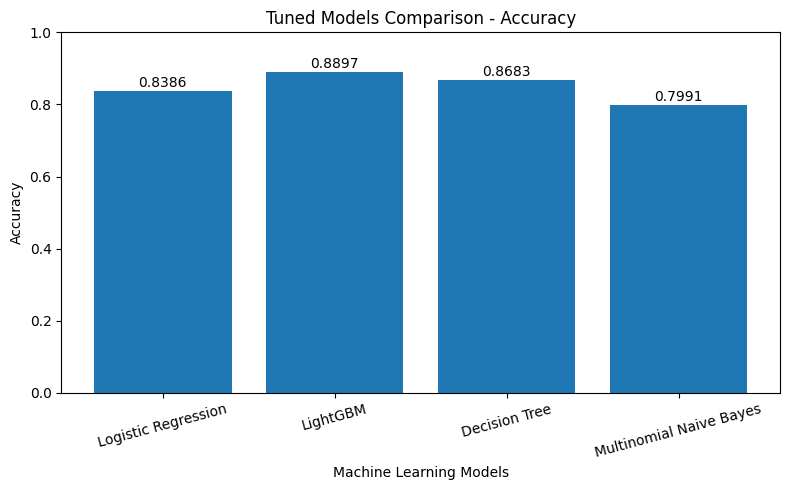

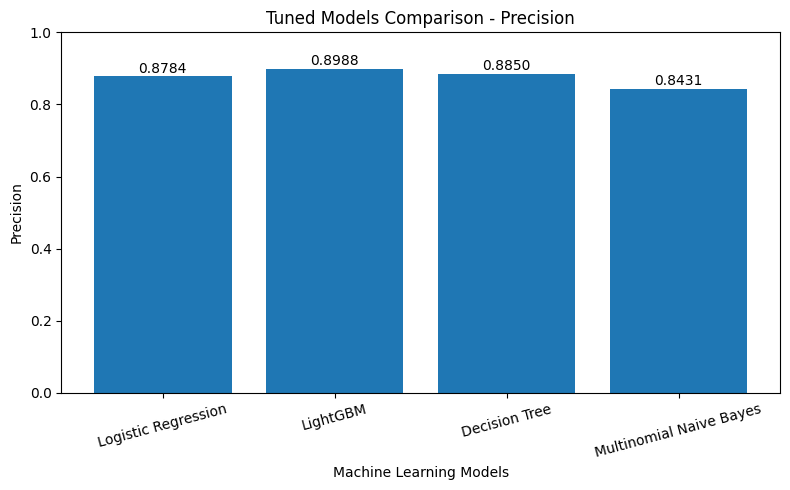

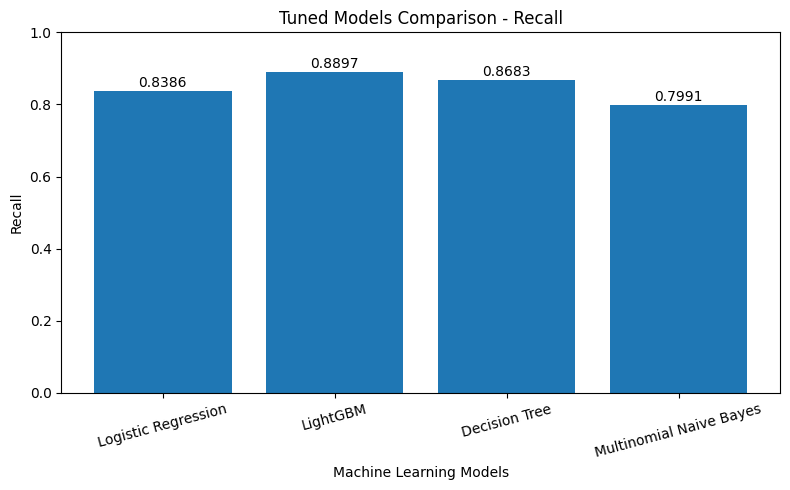

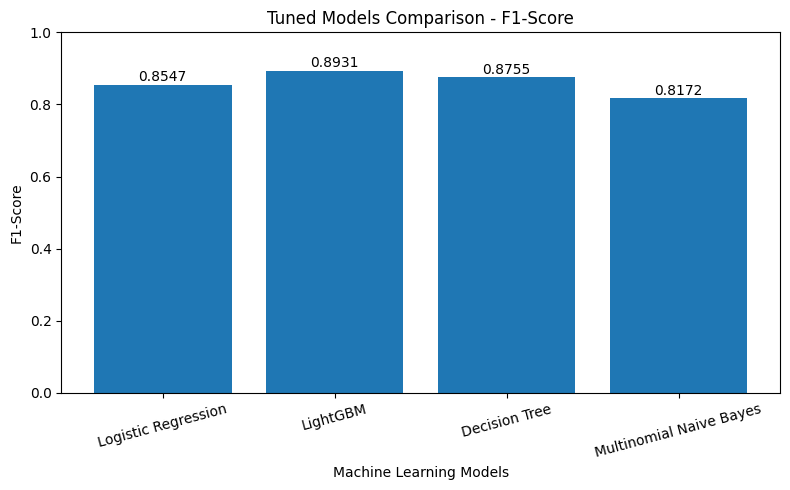

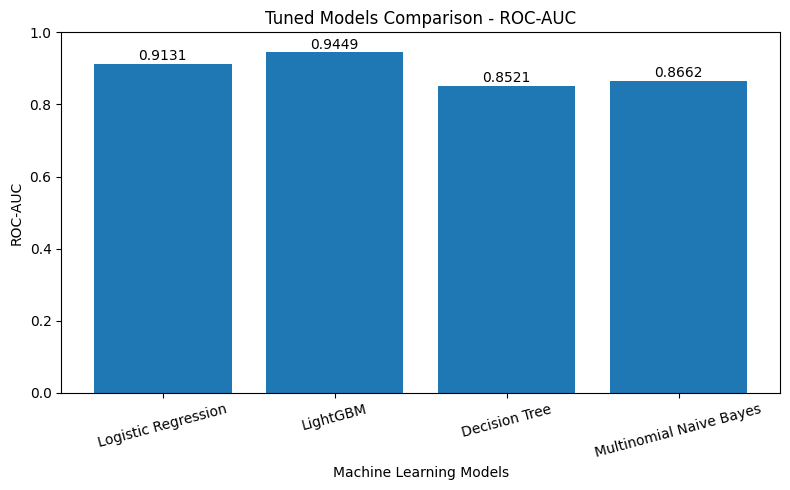

In [28]:
# I imported the required library.
import matplotlib.pyplot as plt

# I defined the metrics to plot.
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

# I generated a graph for each metric.
for metric in metrics:

    plt.figure(figsize=(8, 5))

    plt.bar(
        tuned_results["Model"],
        tuned_results[metric]
    )

    plt.title(f"Tuned Models Comparison - {metric}")
    plt.xlabel("Machine Learning Models")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.ylim(0, 1)

    # I displayed the metric values.
    for i, value in enumerate(tuned_results[metric]):
        plt.text(
            i,
            value + 0.01,
            f"{value:.4f}",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

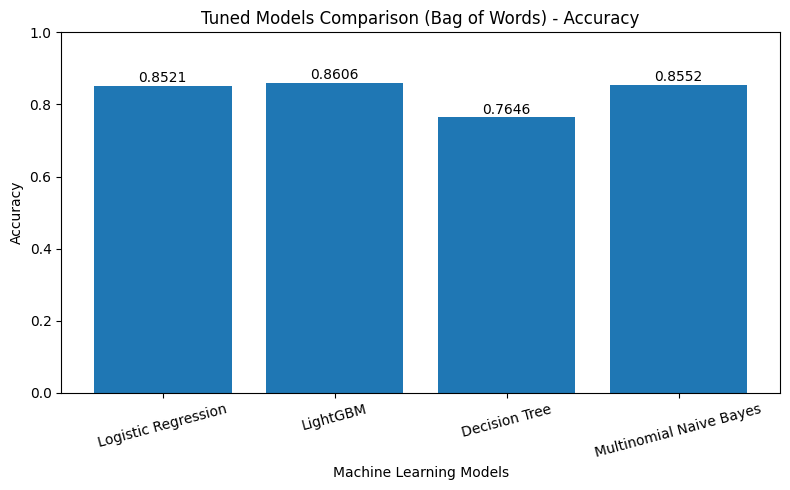

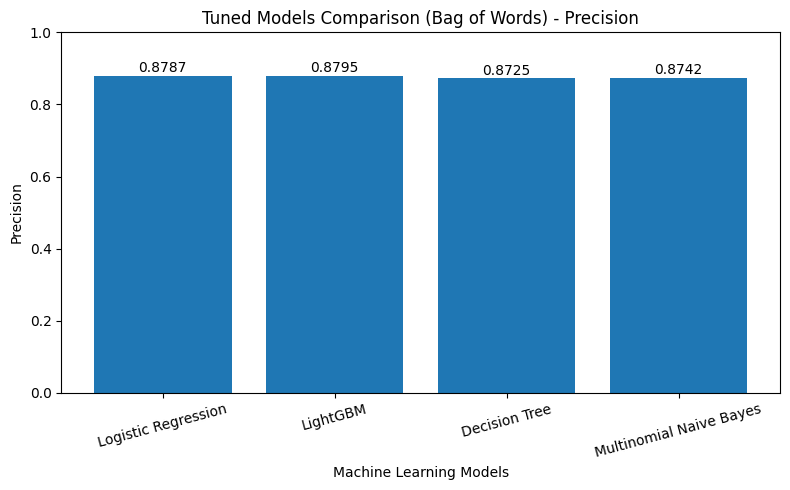

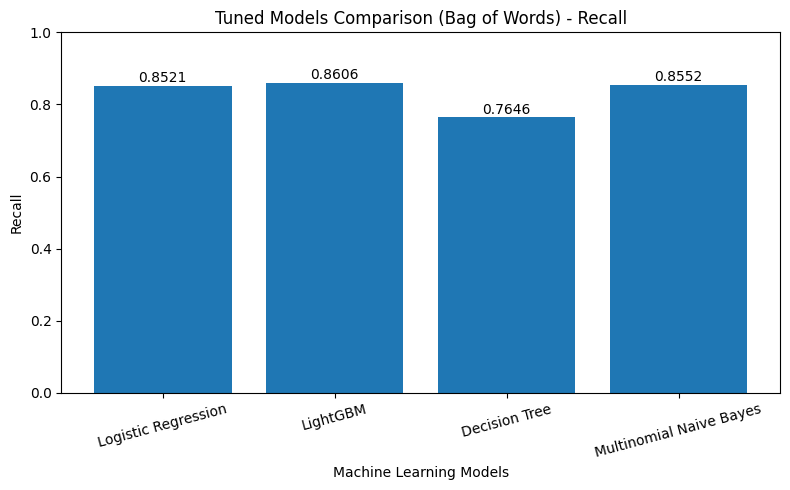

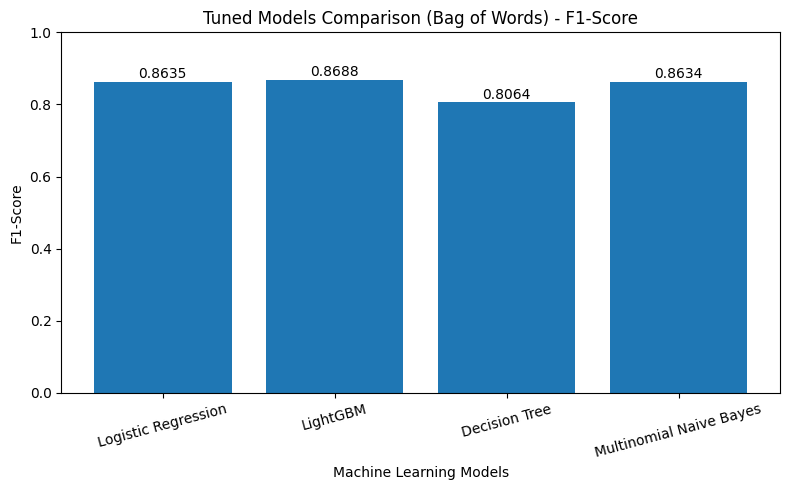

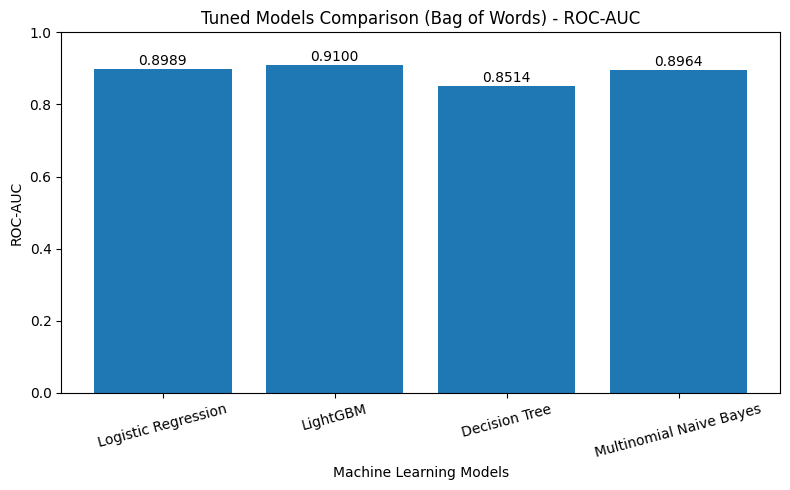

In [30]:
# I imported the required library.
import matplotlib.pyplot as plt

# I defined the metrics to plot.
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

# I generated a graph for each metric.
for metric in metrics:

    plt.figure(figsize=(8, 5))

    plt.bar(
        tuned_results_bow["Model"],
        tuned_results_bow[metric]
    )

    plt.title(f"Tuned Models Comparison (Bag of Words) - {metric}")
    plt.xlabel("Machine Learning Models")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.ylim(0, 1)

    # I displayed the metric values.
    for i, value in enumerate(tuned_results_bow[metric]):
        plt.text(
            i,
            value + 0.01,
            f"{value:.4f}",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

# Combined Comparative Bar Graph for all Tuned Models 

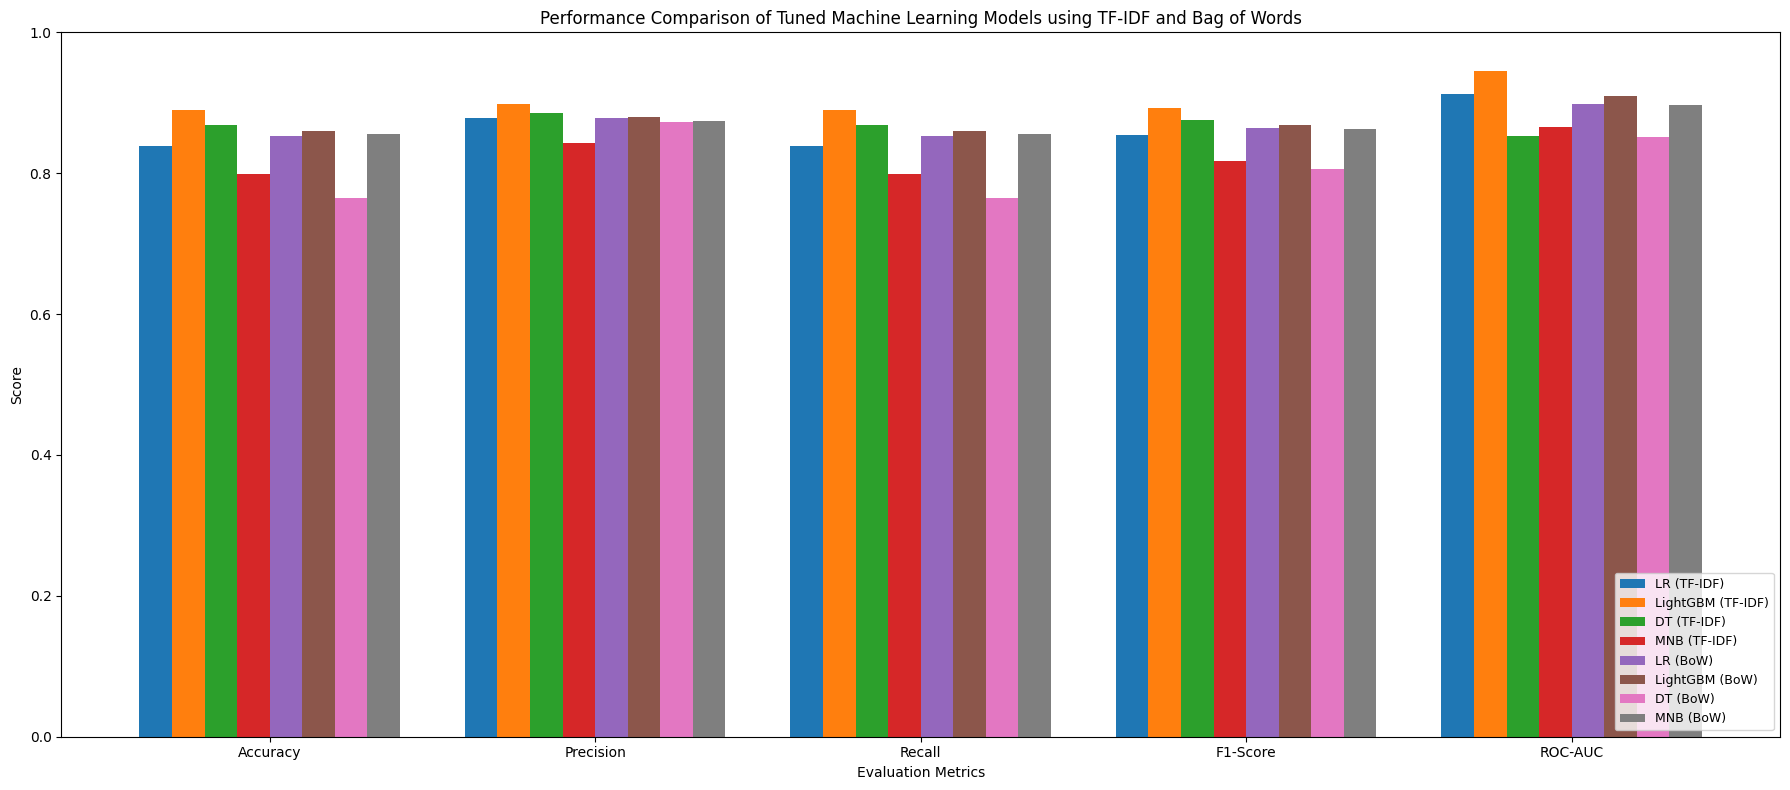

In [32]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the evaluation metrics.
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

# I defined the performance scores.
lr_tfidf = [
    tuned_lr_tf_idf_accuracy,
    tuned_lr_tf_idf_precision,
    tuned_lr_tf_idf_recall,
    tuned_lr_tf_idf_f1_score,
    tuned_lr_tf_idf_auc
]

lightgbm_tfidf = [
    tuned_lightgbm_tf_idf_accuracy,
    tuned_lightgbm_tf_idf_precision,
    tuned_lightgbm_tf_idf_recall,
    tuned_lightgbm_tf_idf_f1_score,
    tuned_lightgbm_tf_idf_auc
]

decision_tree_tfidf = [
    tuned_decision_tree_tf_idf_accuracy,
    tuned_decision_tree_tf_idf_precision,
    tuned_decision_tree_tf_idf_recall,
    tuned_decision_tree_tf_idf_f1_score,
    tuned_decision_tree_tf_idf_auc
]

naive_bayes_tfidf = [
    tuned_naive_bayes_tf_idf_accuracy,
    tuned_naive_bayes_tf_idf_precision,
    tuned_naive_bayes_tf_idf_recall,
    tuned_naive_bayes_tf_idf_f1_score,
    tuned_naive_bayes_tf_idf_auc
]

lr_bow = [
    tuned_lr_bow_accuracy,
    tuned_lr_bow_precision,
    tuned_lr_bow_recall,
    tuned_lr_bow_f1_score,
    tuned_lr_bow_auc
]

lightgbm_bow = [
    tuned_lightgbm_bow_accuracy,
    tuned_lightgbm_bow_precision,
    tuned_lightgbm_bow_recall,
    tuned_lightgbm_bow_f1_score,
    tuned_lightgbm_bow_auc
]

decision_tree_bow = [
    tuned_decision_tree_bow_accuracy,
    tuned_decision_tree_bow_precision,
    tuned_decision_tree_bow_recall,
    tuned_decision_tree_bow_f1_score,
    tuned_decision_tree_bow_auc
]

naive_bayes_bow = [
    tuned_naive_bayes_bow_accuracy,
    tuned_naive_bayes_bow_precision,
    tuned_naive_bayes_bow_recall,
    tuned_naive_bayes_bow_f1_score,
    tuned_naive_bayes_bow_auc
]

# I defined the x-axis positions.
x = np.arange(len(metrics))
width = 0.10

# I created the figure.
plt.figure(figsize=(18,8))

# I plotted all tuned models.
plt.bar(x - 3.5*width, lr_tfidf, width, label="LR (TF-IDF)")
plt.bar(x - 2.5*width, lightgbm_tfidf, width, label="LightGBM (TF-IDF)")
plt.bar(x - 1.5*width, decision_tree_tfidf, width, label="DT (TF-IDF)")
plt.bar(x - 0.5*width, naive_bayes_tfidf, width, label="MNB (TF-IDF)")

plt.bar(x + 0.5*width, lr_bow, width, label="LR (BoW)")
plt.bar(x + 1.5*width, lightgbm_bow, width, label="LightGBM (BoW)")
plt.bar(x + 2.5*width, decision_tree_bow, width, label="DT (BoW)")
plt.bar(x + 3.5*width, naive_bayes_bow, width, label="MNB (BoW)")

# I customized the graph.
plt.title("Performance Comparison of Tuned Machine Learning Models using TF-IDF and Bag of Words")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend(loc="lower right", fontsize=9)

plt.tight_layout()

# I displayed the graph.
plt.show()

# Combined ROC-AUC Curve for all Tuned Models 

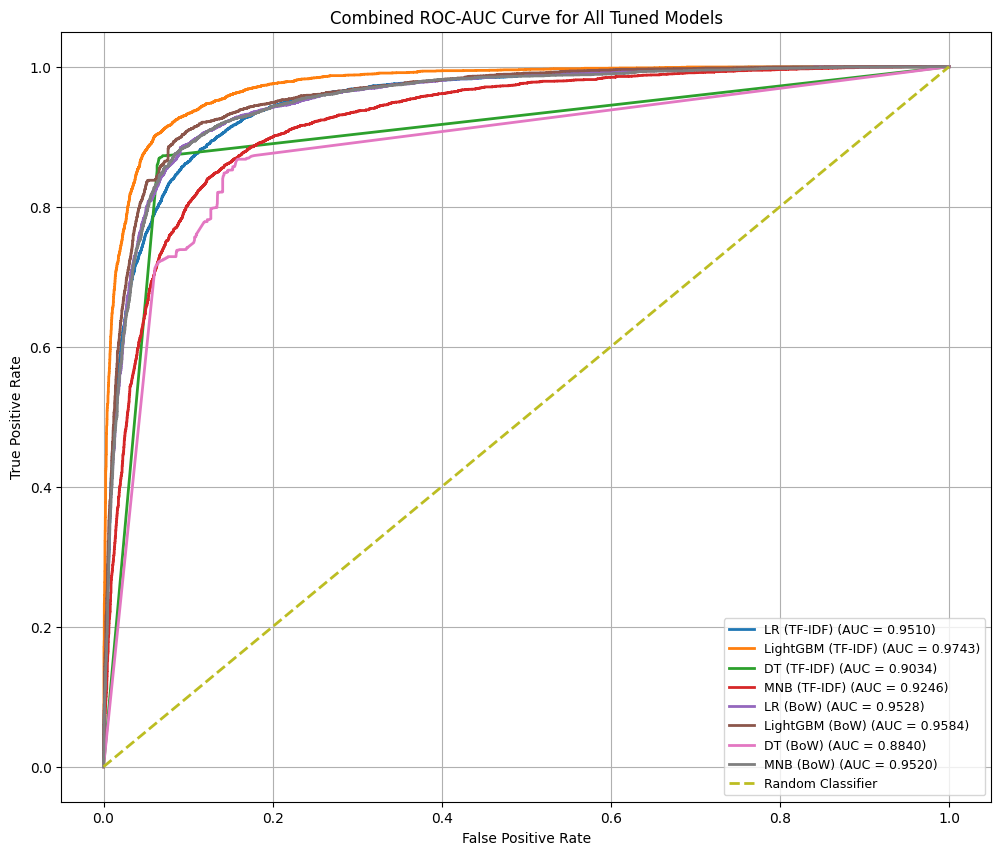

In [33]:
# I imported the required libraries.
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# I binarized the true labels.
y_test_bin = label_binarize(
    y_test,
    classes=sorted(y_test.unique())
)

plt.figure(figsize=(12, 10))

# Logistic Regression (TF-IDF)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_lr_tf_idf.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LR (TF-IDF) (AUC = {roc_auc:.4f})"
)

# LightGBM (TF-IDF)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_lightgbm_tf_idf.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LightGBM (TF-IDF) (AUC = {roc_auc:.4f})"
)

# Decision Tree (TF-IDF)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_decision_tree_tf_idf.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"DT (TF-IDF) (AUC = {roc_auc:.4f})"
)

# Multinomial Naive Bayes (TF-IDF)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_naive_bayes_tf_idf.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MNB (TF-IDF) (AUC = {roc_auc:.4f})"
)

# Logistic Regression (BoW)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_lr_bow.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LR (BoW) (AUC = {roc_auc:.4f})"
)

# LightGBM (BoW)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_lightgbm_bow.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LightGBM (BoW) (AUC = {roc_auc:.4f})"
)

# Decision Tree (BoW)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_decision_tree_bow.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"DT (BoW) (AUC = {roc_auc:.4f})"
)

# Multinomial Naive Bayes (BoW)
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_prob_tuned_naive_bayes_bow.ravel()
)
roc_auc = auc(fpr, tpr)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"MNB (BoW) (AUC = {roc_auc:.4f})"
)

# Random classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

# I customized the graph.
plt.title("Combined ROC-AUC Curve for All Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)

# I displayed the graph.
plt.show()

# Combined Comparative Table for all Default and Tuned Models 

In [34]:
# I created one combined comparison table for all default and tuned models.

comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM",
        "Decision Tree",
        "Multinomial Naive Bayes"
    ],

    "TF-IDF Default Accuracy": [
        lr_tfidf_accuracy,
        lightgbm_tfidf_accuracy,
        decision_tree_tfidf_accuracy,
        naive_bayes_tfidf_accuracy
    ],

    "TF-IDF Tuned Accuracy": [
        tuned_lr_tf_idf_accuracy,
        tuned_lightgbm_tf_idf_accuracy,
        tuned_decision_tree_tf_idf_accuracy,
        tuned_naive_bayes_tf_idf_accuracy
    ],

    "BoW Default Accuracy": [
        lr_bow_accuracy,
        lightgbm_bow_accuracy,
        decision_tree_bow_accuracy,
        naive_bayes_bow_accuracy
    ],

    "BoW Tuned Accuracy": [
        tuned_lr_bow_accuracy,
        tuned_lightgbm_bow_accuracy,
        tuned_decision_tree_bow_accuracy,
        tuned_naive_bayes_bow_accuracy
    ],

    "TF-IDF Default Precision": [
        lr_tfidf_precision,
        lightgbm_tfidf_precision,
        decision_tree_tfidf_precision,
        naive_bayes_tfidf_precision
    ],

    "TF-IDF Tuned Precision": [
        tuned_lr_tf_idf_precision,
        tuned_lightgbm_tf_idf_precision,
        tuned_decision_tree_tf_idf_precision,
        tuned_naive_bayes_tf_idf_precision
    ],

    "BoW Default Precision": [
        lr_bow_precision,
        lightgbm_bow_precision,
        decision_tree_bow_precision,
        naive_bayes_bow_precision
    ],

    "BoW Tuned Precision": [
        tuned_lr_bow_precision,
        tuned_lightgbm_bow_precision,
        tuned_decision_tree_bow_precision,
        tuned_naive_bayes_bow_precision
    ],

    "TF-IDF Default Recall": [
        lr_tfidf_recall,
        lightgbm_tfidf_recall,
        decision_tree_tfidf_recall,
        naive_bayes_tfidf_recall
    ],

    "TF-IDF Tuned Recall": [
        tuned_lr_tf_idf_recall,
        tuned_lightgbm_tf_idf_recall,
        tuned_decision_tree_tf_idf_recall,
        tuned_naive_bayes_tf_idf_recall
    ],

    "BoW Default Recall": [
        lr_bow_recall,
        lightgbm_bow_recall,
        decision_tree_bow_recall,
        naive_bayes_bow_recall
    ],

    "BoW Tuned Recall": [
        tuned_lr_bow_recall,
        tuned_lightgbm_bow_recall,
        tuned_decision_tree_bow_recall,
        tuned_naive_bayes_bow_recall
    ],

    "TF-IDF Default F1-Score": [
        lr_tfidf_f1_score,
        lightgbm_tfidf_f1_score,
        decision_tree_tfidf_f1_score,
        naive_bayes_tfidf_f1_score
    ],

    "TF-IDF Tuned F1-Score": [
        tuned_lr_tf_idf_f1_score,
        tuned_lightgbm_tf_idf_f1_score,
        tuned_decision_tree_tf_idf_f1_score,
        tuned_naive_bayes_tf_idf_f1_score
    ],

    "BoW Default F1-Score": [
        lr_bow_f1_score,
        lightgbm_bow_f1_score,
        decision_tree_bow_f1_score,
        naive_bayes_bow_f1_score
    ],

    "BoW Tuned F1-Score": [
        tuned_lr_bow_f1_score,
        tuned_lightgbm_bow_f1_score,
        tuned_decision_tree_bow_f1_score,
        tuned_naive_bayes_bow_f1_score
    ],

    "TF-IDF Default ROC-AUC": [
        lr_tfidf_auc,
        lightgbm_tfidf_auc,
        decision_tree_tfidf_auc,
        naive_bayes_tfidf_auc
    ],

    "TF-IDF Tuned ROC-AUC": [
        tuned_lr_tf_idf_auc,
        tuned_lightgbm_tf_idf_auc,
        tuned_decision_tree_tf_idf_auc,
        tuned_naive_bayes_tf_idf_auc
    ],

    "BoW Default ROC-AUC": [
        lr_bow_auc,
        lightgbm_bow_auc,
        decision_tree_bow_auc,
        naive_bayes_bow_auc
    ],

    "BoW Tuned ROC-AUC": [
        tuned_lr_bow_auc,
        tuned_lightgbm_bow_auc,
        tuned_decision_tree_bow_auc,
        tuned_naive_bayes_bow_auc
    ]
})

comparison_results = comparison_results.round(4)

print("Combined Comparative Table for Default and Tuned Models (TF-IDF and Bag of Words)")
display(comparison_results)

Combined Comparative Table for Default and Tuned Models (TF-IDF and Bag of Words)


,Model,TF-IDF Default Accuracy,TF-IDF Tuned Accuracy,BoW Default Accuracy,BoW Tuned Accuracy,TF-IDF Default Precision,TF-IDF Tuned Precision,BoW Default Precision,BoW Tuned Precision,TF-IDF Default Recall,TF-IDF Tuned Recall,BoW Default Recall,BoW Tuned Recall,TF-IDF Default F1-Score,TF-IDF Tuned F1-Score,BoW Default F1-Score,BoW Tuned F1-Score,TF-IDF Default ROC-AUC,TF-IDF Tuned ROC-AUC,BoW Default ROC-AUC,BoW Tuned ROC-AUC
0,Logistic Regression,0.8477,0.8386,0.8521,0.8521,0.8918,0.8784,0.8787,0.8787,0.8477,0.8386,0.8521,0.8521,0.8637,0.8547,0.8635,0.8635,0.9301,0.9131,0.8989,0.8989
1,LightGBM,0.8838,0.8897,0.8759,0.8606,0.9024,0.8988,0.8880,0.8795,0.8838,0.8897,0.8759,0.8606,0.8907,0.8931,0.8810,0.8688,0.9477,0.9449,0.9170,0.9100
2,Decision Tree,0.8683,0.8683,0.7527,0.7646,0.8850,0.8850,0.8669,0.8725,0.8683,0.8683,0.7527,0.7646,0.8755,0.8755,0.7974,0.8064,0.8521,0.8521,0.8381,0.8514
3,Multinomial Naive Bayes,0.8104,0.7991,0.8566,0.8552,0.8647,0.8431,0.8778,0.8742,0.8104,0.7991,0.8566,0.8552,0.8315,0.8172,0.8657,0.8634,0.8992,0.8662,0.8993,0.8964


# Visual Analysis 

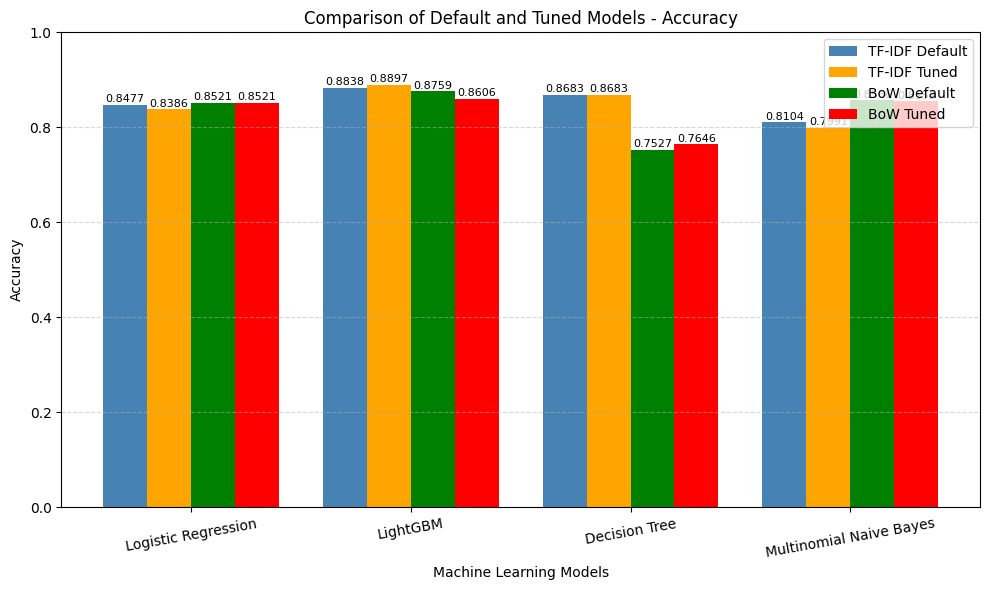

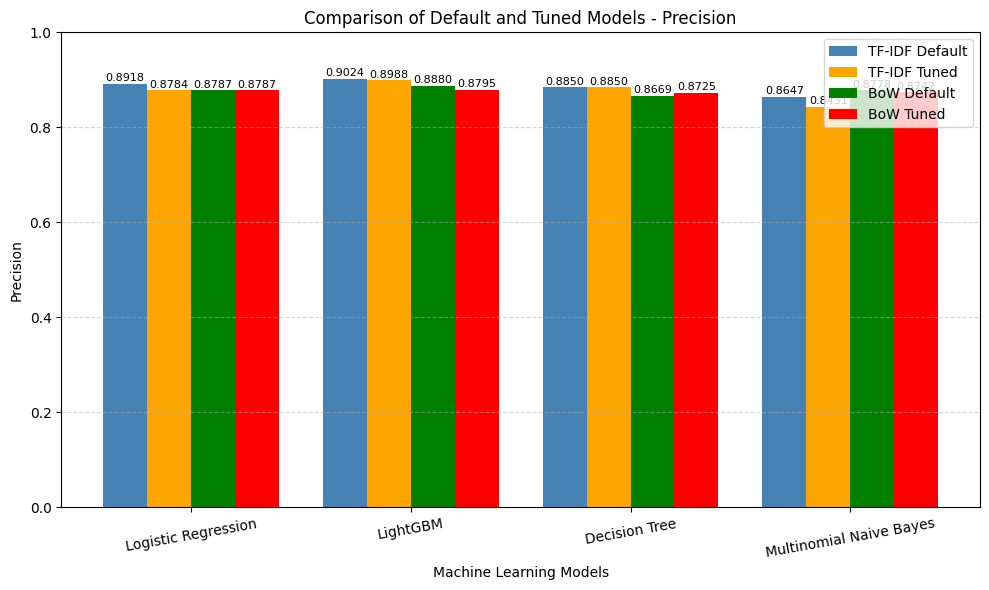

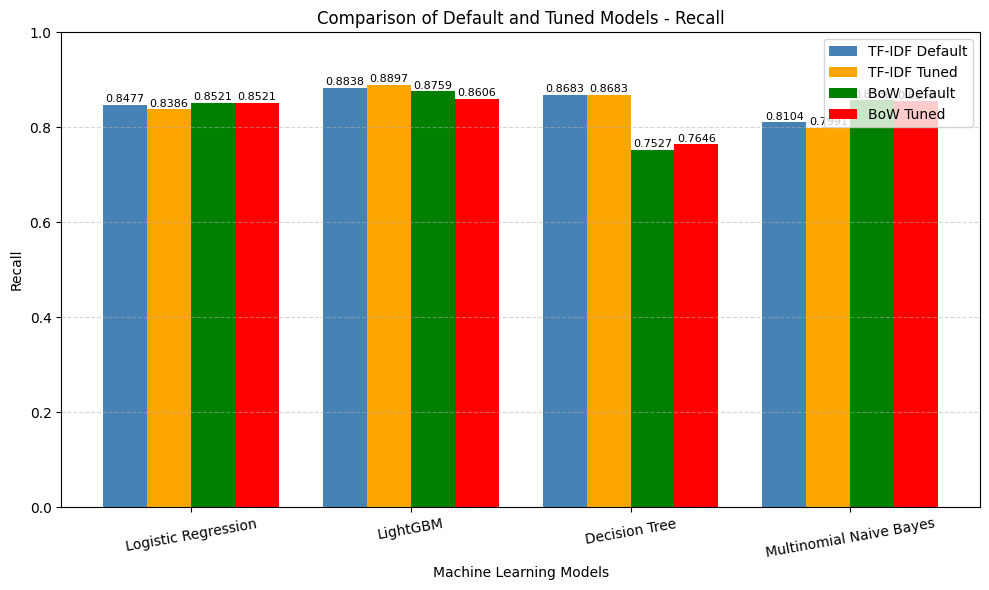

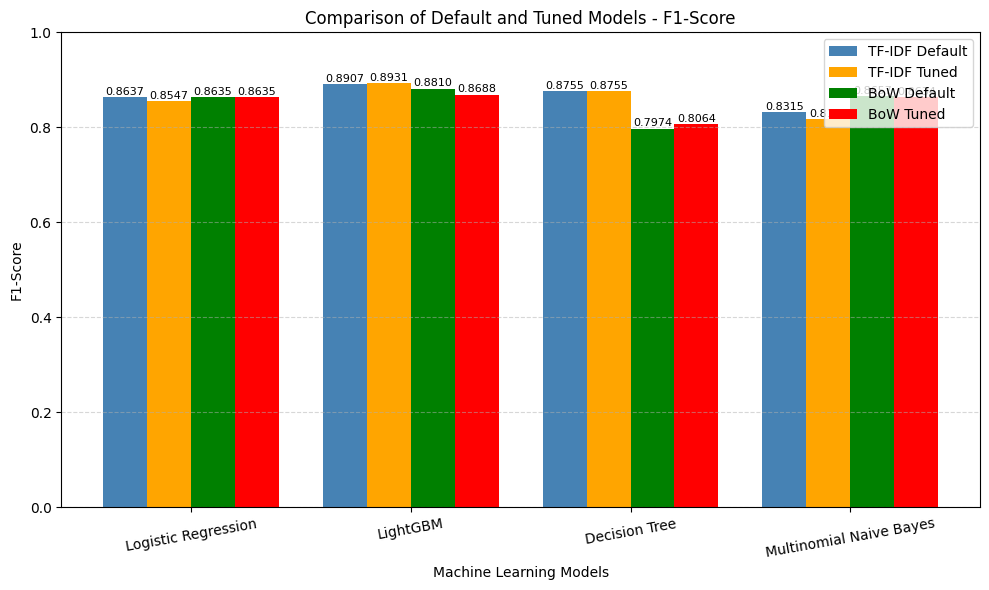

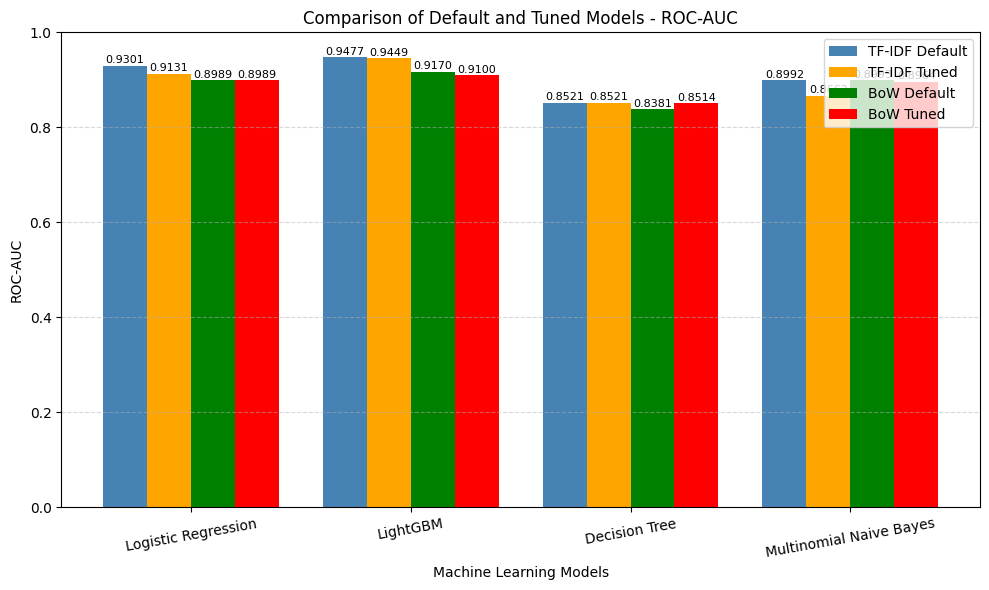

In [35]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the evaluation metrics.
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

# I defined different colors.
colors = [
    "steelblue",
    "orange",
    "green",
    "red"
]

# I generated a graph for each evaluation metric.
for metric in metrics:

    plt.figure(figsize=(10,6))

    x = np.arange(len(comparison_results["Model"]))
    width = 0.20

    plt.bar(
        x - 1.5*width,
        comparison_results[f"TF-IDF Default {metric}"],
        width,
        color=colors[0],
        label="TF-IDF Default"
    )

    plt.bar(
        x - 0.5*width,
        comparison_results[f"TF-IDF Tuned {metric}"],
        width,
        color=colors[1],
        label="TF-IDF Tuned"
    )

    plt.bar(
        x + 0.5*width,
        comparison_results[f"BoW Default {metric}"],
        width,
        color=colors[2],
        label="BoW Default"
    )

    plt.bar(
        x + 1.5*width,
        comparison_results[f"BoW Tuned {metric}"],
        width,
        color=colors[3],
        label="BoW Tuned"
    )

    # I added the metric values.
    for i in range(len(x)):
        plt.text(
            x[i]-1.5*width,
            comparison_results[f"TF-IDF Default {metric}"][i]+0.005,
            f"{comparison_results[f'TF-IDF Default {metric}'][i]:.4f}",
            ha="center",
            fontsize=8
        )

        plt.text(
            x[i]-0.5*width,
            comparison_results[f"TF-IDF Tuned {metric}"][i]+0.005,
            f"{comparison_results[f'TF-IDF Tuned {metric}'][i]:.4f}",
            ha="center",
            fontsize=8
        )

        plt.text(
            x[i]+0.5*width,
            comparison_results[f"BoW Default {metric}"][i]+0.005,
            f"{comparison_results[f'BoW Default {metric}'][i]:.4f}",
            ha="center",
            fontsize=8
        )

        plt.text(
            x[i]+1.5*width,
            comparison_results[f"BoW Tuned {metric}"][i]+0.005,
            f"{comparison_results[f'BoW Tuned {metric}'][i]:.4f}",
            ha="center",
            fontsize=8
        )

    plt.title(f"Comparison of Default and Tuned Models - {metric}")
    plt.xlabel("Machine Learning Models")
    plt.ylabel(metric)
    plt.xticks(x, comparison_results["Model"], rotation=10)
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

# Combined Comparative Bar Graph for Default and Tuned Models for Both Techniques 

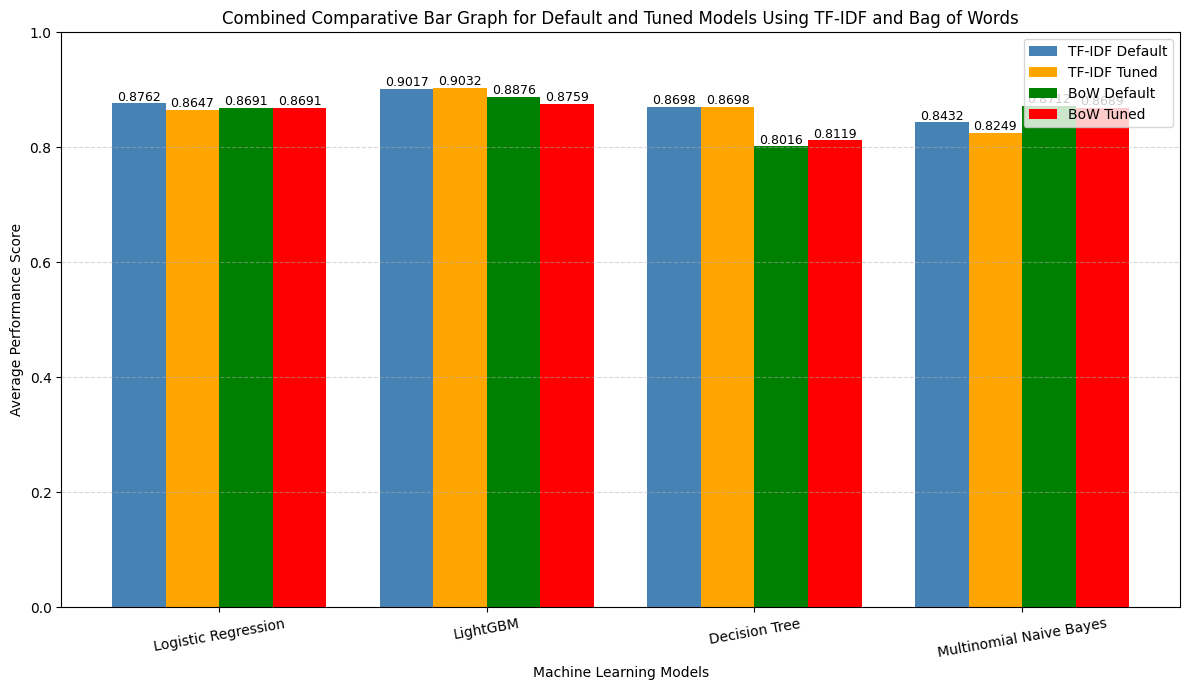

In [36]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I calculated the average performance across all evaluation metrics.
comparison_results["TF-IDF Default Mean"] = comparison_results[
    [
        "TF-IDF Default Accuracy",
        "TF-IDF Default Precision",
        "TF-IDF Default Recall",
        "TF-IDF Default F1-Score",
        "TF-IDF Default ROC-AUC"
    ]
].mean(axis=1)

comparison_results["TF-IDF Tuned Mean"] = comparison_results[
    [
        "TF-IDF Tuned Accuracy",
        "TF-IDF Tuned Precision",
        "TF-IDF Tuned Recall",
        "TF-IDF Tuned F1-Score",
        "TF-IDF Tuned ROC-AUC"
    ]
].mean(axis=1)

comparison_results["BoW Default Mean"] = comparison_results[
    [
        "BoW Default Accuracy",
        "BoW Default Precision",
        "BoW Default Recall",
        "BoW Default F1-Score",
        "BoW Default ROC-AUC"
    ]
].mean(axis=1)

comparison_results["BoW Tuned Mean"] = comparison_results[
    [
        "BoW Tuned Accuracy",
        "BoW Tuned Precision",
        "BoW Tuned Recall",
        "BoW Tuned F1-Score",
        "BoW Tuned ROC-AUC"
    ]
].mean(axis=1)

# I created the grouped bar graph.
x = np.arange(len(comparison_results["Model"]))
width = 0.20

plt.figure(figsize=(12,7))

plt.bar(
    x - 1.5*width,
    comparison_results["TF-IDF Default Mean"],
    width,
    color="steelblue",
    label="TF-IDF Default"
)

plt.bar(
    x - 0.5*width,
    comparison_results["TF-IDF Tuned Mean"],
    width,
    color="orange",
    label="TF-IDF Tuned"
)

plt.bar(
    x + 0.5*width,
    comparison_results["BoW Default Mean"],
    width,
    color="green",
    label="BoW Default"
)

plt.bar(
    x + 1.5*width,
    comparison_results["BoW Tuned Mean"],
    width,
    color="red",
    label="BoW Tuned"
)

# I added value labels.
for i in range(len(x)):

    plt.text(
        x[i]-1.5*width,
        comparison_results["TF-IDF Default Mean"][i]+0.005,
        f"{comparison_results['TF-IDF Default Mean'][i]:.4f}",
        ha="center",
        fontsize=9
    )

    plt.text(
        x[i]-0.5*width,
        comparison_results["TF-IDF Tuned Mean"][i]+0.005,
        f"{comparison_results['TF-IDF Tuned Mean'][i]:.4f}",
        ha="center",
        fontsize=9
    )

    plt.text(
        x[i]+0.5*width,
        comparison_results["BoW Default Mean"][i]+0.005,
        f"{comparison_results['BoW Default Mean'][i]:.4f}",
        ha="center",
        fontsize=9
    )

    plt.text(
        x[i]+1.5*width,
        comparison_results["BoW Tuned Mean"][i]+0.005,
        f"{comparison_results['BoW Tuned Mean'][i]:.4f}",
        ha="center",
        fontsize=9
    )

# I customized the graph.
plt.title("Combined Comparative Bar Graph for Default and Tuned Models Using TF-IDF and Bag of Words")
plt.xlabel("Machine Learning Models")
plt.ylabel("Average Performance Score")
plt.xticks(x, comparison_results["Model"], rotation=10)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Best Perfoming Model

                             Model  Accuracy  Precision    Recall  F1-Score  \
3          LightGBM (TF-IDF Tuned)  0.889651   0.898778  0.889651  0.893124   
2        LightGBM (TF-IDF Default)  0.883801   0.902446  0.883801  0.890713   
10          LightGBM (BoW Default)  0.875933   0.888010  0.875933  0.880972   
0              LR (TF-IDF Default)  0.847690   0.891820  0.847690  0.863673   
11            LightGBM (BoW Tuned)  0.860601   0.879535  0.860601  0.868812   
14       Naive Bayes (BoW Default)  0.856566   0.877771  0.856566  0.865655   
4   Decision Tree (TF-IDF Default)  0.868267   0.884955  0.868267  0.875526   
5     Decision Tree (TF-IDF Tuned)  0.868267   0.884955  0.868267  0.875526   
8                 LR (BoW Default)  0.852128   0.878720  0.852128  0.863494   
9                   LR (BoW Tuned)  0.852128   0.878720  0.852128  0.863494   
15         Naive Bayes (BoW Tuned)  0.855154   0.874171  0.855154  0.863407   
1                LR (TF-IDF Tuned)  0.838612   0.878

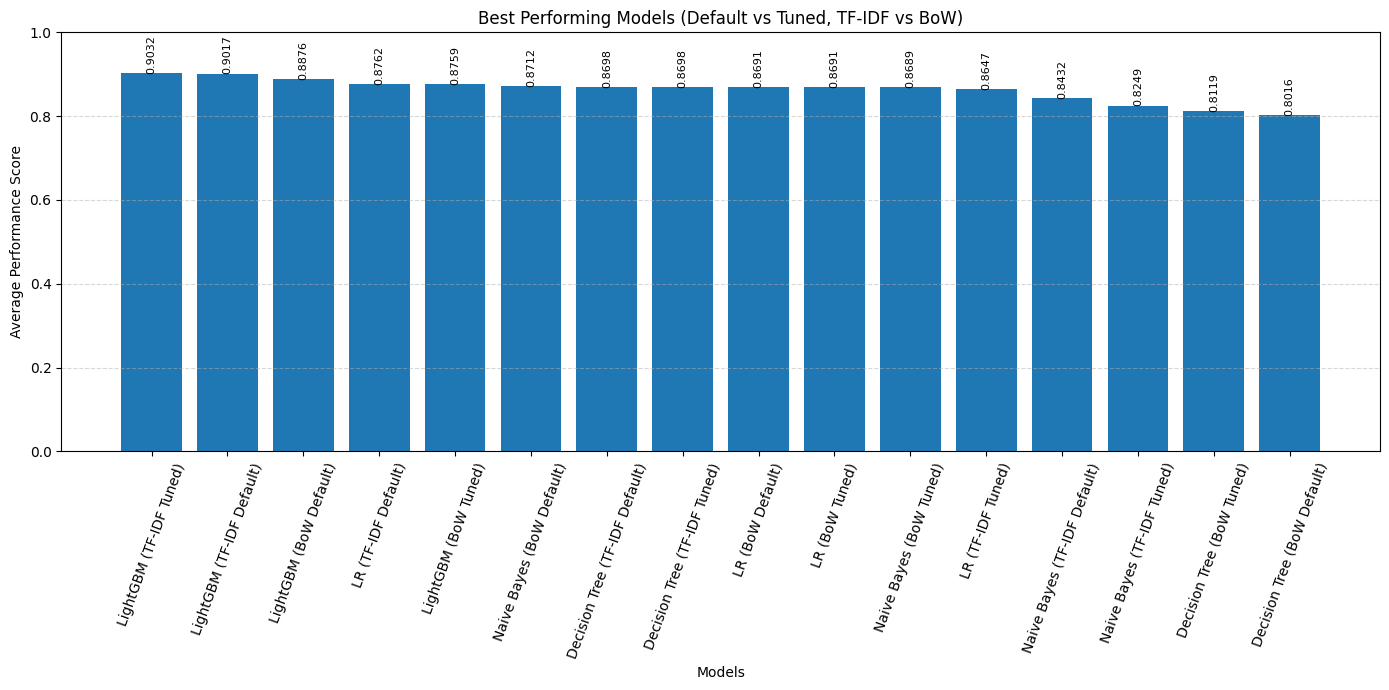

In [38]:
# I imported the required libraries.
import pandas as pd
import matplotlib.pyplot as plt

# I created a dataframe containing all models.
best_models = pd.DataFrame({

    "Model": [
        "LR (TF-IDF Default)",
        "LR (TF-IDF Tuned)",
        "LightGBM (TF-IDF Default)",
        "LightGBM (TF-IDF Tuned)",
        "Decision Tree (TF-IDF Default)",
        "Decision Tree (TF-IDF Tuned)",
        "Naive Bayes (TF-IDF Default)",
        "Naive Bayes (TF-IDF Tuned)",

        "LR (BoW Default)",
        "LR (BoW Tuned)",
        "LightGBM (BoW Default)",
        "LightGBM (BoW Tuned)",
        "Decision Tree (BoW Default)",
        "Decision Tree (BoW Tuned)",
        "Naive Bayes (BoW Default)",
        "Naive Bayes (BoW Tuned)"
    ],

    "Accuracy": [
        lr_tfidf_accuracy,
        tuned_lr_tf_idf_accuracy,
        lightgbm_tfidf_accuracy,
        tuned_lightgbm_tf_idf_accuracy,
        decision_tree_tfidf_accuracy,
        tuned_decision_tree_tf_idf_accuracy,
        naive_bayes_tfidf_accuracy,
        tuned_naive_bayes_tf_idf_accuracy,

        lr_bow_accuracy,
        tuned_lr_bow_accuracy,
        lightgbm_bow_accuracy,
        tuned_lightgbm_bow_accuracy,
        decision_tree_bow_accuracy,
        tuned_decision_tree_bow_accuracy,
        naive_bayes_bow_accuracy,
        tuned_naive_bayes_bow_accuracy
    ],

    "Precision": [
        lr_tfidf_precision,
        tuned_lr_tf_idf_precision,
        lightgbm_tfidf_precision,
        tuned_lightgbm_tf_idf_precision,
        decision_tree_tfidf_precision,
        tuned_decision_tree_tf_idf_precision,
        naive_bayes_tfidf_precision,
        tuned_naive_bayes_tf_idf_precision,

        lr_bow_precision,
        tuned_lr_bow_precision,
        lightgbm_bow_precision,
        tuned_lightgbm_bow_precision,
        decision_tree_bow_precision,
        tuned_decision_tree_bow_precision,
        naive_bayes_bow_precision,
        tuned_naive_bayes_bow_precision
    ],

    "Recall": [
        lr_tfidf_recall,
        tuned_lr_tf_idf_recall,
        lightgbm_tfidf_recall,
        tuned_lightgbm_tf_idf_recall,
        decision_tree_tfidf_recall,
        tuned_decision_tree_tf_idf_recall,
        naive_bayes_tfidf_recall,
        tuned_naive_bayes_tf_idf_recall,

        lr_bow_recall,
        tuned_lr_bow_recall,
        lightgbm_bow_recall,
        tuned_lightgbm_bow_recall,
        decision_tree_bow_recall,
        tuned_decision_tree_bow_recall,
        naive_bayes_bow_recall,
        tuned_naive_bayes_bow_recall
    ],

    "F1-Score": [
        lr_tfidf_f1_score,
        tuned_lr_tf_idf_f1_score,
        lightgbm_tfidf_f1_score,
        tuned_lightgbm_tf_idf_f1_score,
        decision_tree_tfidf_f1_score,
        tuned_decision_tree_tf_idf_f1_score,
        naive_bayes_tfidf_f1_score,
        tuned_naive_bayes_tf_idf_f1_score,

        lr_bow_f1_score,
        tuned_lr_bow_f1_score,
        lightgbm_bow_f1_score,
        tuned_lightgbm_bow_f1_score,
        decision_tree_bow_f1_score,
        tuned_decision_tree_bow_f1_score,
        naive_bayes_bow_f1_score,
        tuned_naive_bayes_bow_f1_score
    ],

    "ROC-AUC": [
        lr_tfidf_auc,
        tuned_lr_tf_idf_auc,
        lightgbm_tfidf_auc,
        tuned_lightgbm_tf_idf_auc,
        decision_tree_tfidf_auc,
        tuned_decision_tree_tf_idf_auc,
        naive_bayes_tfidf_auc,
        tuned_naive_bayes_tf_idf_auc,

        lr_bow_auc,
        tuned_lr_bow_auc,
        lightgbm_bow_auc,
        tuned_lightgbm_bow_auc,
        decision_tree_bow_auc,
        tuned_decision_tree_bow_auc,
        naive_bayes_bow_auc,
        tuned_naive_bayes_bow_auc
    ]
})

# I calculated the average performance score.
best_models["Average Score"] = best_models[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].mean(axis=1)

# I sorted the models from best to worst.
best_models = best_models.sort_values(
    by="Average Score",
    ascending=False
)

print(best_models)

# I plotted the graph.
plt.figure(figsize=(14,7))

bars = plt.bar(
    best_models["Model"],
    best_models["Average Score"]
)

# I added values on bars.
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=8,
        rotation=90
    )

plt.title("Best Performing Models (Default vs Tuned, TF-IDF vs BoW)")
plt.xlabel("Models")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=70)
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [39]:
# I identified the best-performing model.
best_model = best_models.iloc[0]


print("BEST PERFORMING MODEL")


print(f"Model                : {best_model['Model']}")
print(f"Average Score        : {best_model['Average Score']:.4f}")
print(f"Accuracy             : {best_model['Accuracy']:.4f}")
print(f"Precision            : {best_model['Precision']:.4f}")
print(f"Recall               : {best_model['Recall']:.4f}")
print(f"F1-Score             : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC              : {best_model['ROC-AUC']:.4f}")

print("\nReason for Selection:")
print("- It achieved the highest average score across all evaluation metrics.")
print("- It provides the best balance between Accuracy, Precision, Recall, F1-Score and ROC-AUC.")
print("- A higher Accuracy indicates better overall classification performance.")
print("- A higher Precision reduces false positive predictions.")
print("- A higher Recall improves the detection of positive instances.")
print("- A higher F1-Score demonstrates a balanced trade-off between Precision and Recall.")
print("- A higher ROC-AUC indicates superior class discrimination capability.")
print("- Therefore, this model was selected as the best-performing model for hate speech classification.")


BEST PERFORMING MODEL
Model                : LightGBM (TF-IDF Tuned)
Average Score        : 0.9032
Accuracy             : 0.8897
Precision            : 0.8988
Recall               : 0.8897
F1-Score             : 0.8931
ROC-AUC              : 0.9449

Reason for Selection:
- It achieved the highest average score across all evaluation metrics.
- It provides the best balance between Accuracy, Precision, Recall, F1-Score and ROC-AUC.
- A higher Accuracy indicates better overall classification performance.
- A higher Precision reduces false positive predictions.
- A higher Recall improves the detection of positive instances.
- A higher F1-Score demonstrates a balanced trade-off between Precision and Recall.
- A higher ROC-AUC indicates superior class discrimination capability.
- Therefore, this model was selected as the best-performing model for hate speech classification.


# GUI Prototype For Classification & Human Evaluation

In [ ]:
import tkinter as tk
from tkinter import messagebox, ttk
from tkinter.scrolledtext import ScrolledText
import joblib
import re
import string
import nltk
import csv
import os
from datetime import datetime
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

try:
    model = joblib.load("multi_best_lightgbm_model.pkl")
    tfidf = joblib.load("multi_tfidf.pkl")
except Exception as e:
    raise SystemExit(f"Error loading model files:\n{e}")

CLASS_NAMES = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neutral Content"
}

EVALUATION_FILE = "human_evaluation_results.csv"


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = [
        w for w in text.split()
        if w not in stop_words
    ]

    words = [
        stemmer.stem(w)
        for w in words
    ]

    return " ".join(words)


root = tk.Tk()

root.title(
    "Prototype for Multi Class Classification and Human Evaluation"
)

root.geometry("1100x800")
root.minsize(900, 650)
root.configure(bg="white")
root.resizable(True, True)

try:
    root.state("zoomed")
except:
    pass


tk.Label(
    root,
    text="Prototype for Multi Class Classification and Human Evaluation",
    font=("Arial", 22, "bold"),
    bg="white"
).pack(pady=20)


tk.Label(
    root,
    text="Enter Text",
    font=("Arial", 14, "bold"),
    bg="white"
).pack(
    anchor="w",
    padx=40
)


text_box = ScrolledText(
    root,
    height=10,
    font=("Arial", 12),
    wrap=tk.WORD
)

text_box.pack(
    fill="x",
    padx=40,
    pady=10
)


result_frame = tk.Frame(
    root,
    bg="white"
)

result_frame.pack(
    fill="x",
    padx=40,
    pady=15
)


tk.Label(
    result_frame,
    text="Prediction Result",
    font=("Arial", 15, "bold"),
    bg="white"
).pack(
    anchor="w",
    pady=(0, 10)
)


prediction_label = tk.Label(
    result_frame,
    text="Predicted Class : -",
    font=("Arial", 14),
    bg="white"
)

prediction_label.pack(
    anchor="w"
)


confidence_label = tk.Label(
    result_frame,
    text="Confidence : -",
    font=("Arial", 14),
    bg="white"
)

confidence_label.pack(
    anchor="w",
    pady=5
)


status_bar = tk.Label(
    root,
    text="Status : Ready",
    bg="#f2f2f2",
    anchor="w",
    padx=10
)

status_bar.pack(
    side="bottom",
    fill="x"
)


current_prediction = None
current_confidence = None
current_text = ""


def predict_text():

    global current_prediction
    global current_confidence
    global current_text

    user_text = text_box.get(
        "1.0",
        tk.END
    ).strip()

    if not user_text:
        messagebox.showwarning(
            "Warning",
            "Please enter some text."
        )
        return

    processed = preprocess_text(
        user_text
    )

    try:
        vector = tfidf.transform(
            [processed]
        )

        prediction = int(
            model.predict(vector)[0]
        )

        probs = model.predict_proba(
            vector
        )[0]

        confidence = (
            probs[prediction] * 100
        )

        current_prediction = prediction
        current_confidence = confidence
        current_text = user_text

        prediction_label.config(
            text=(
                f"Predicted Class : "
                f"{CLASS_NAMES[prediction]}"
            )
        )

        confidence_label.config(
            text=(
                f"Confidence : "
                f"{confidence:.2f}%"
            )
        )

        if prediction == 0:
            prediction_label.config(
                fg="red"
            )
        elif prediction == 1:
            prediction_label.config(
                fg="orange"
            )
        else:
            prediction_label.config(
                fg="green"
            )

        status_bar.config(
            text="Status : Prediction completed successfully."
        )

    except Exception as e:
        messagebox.showerror(
            "Prediction Error",
            str(e)
        )


def clear_text():

    global current_prediction
    global current_confidence
    global current_text

    text_box.delete(
        "1.0",
        tk.END
    )

    prediction_label.config(
        text="Predicted Class : -",
        fg="black"
    )

    confidence_label.config(
        text="Confidence : -"
    )

    current_prediction = None
    current_confidence = None
    current_text = ""

    status_bar.config(
        text="Status : Ready"
    )


def open_human_evaluation():

    if current_prediction is None:
        messagebox.showwarning(
            "Human Evaluation",
            "Please make a prediction before starting the human evaluation."
        )
        return

    evaluation_window = tk.Toplevel(
        root
    )

    evaluation_window.title(
        "Human Evaluation"
    )

    evaluation_window.geometry(
        "900x750"
    )

    evaluation_window.minsize(
        700,
        600
    )

    evaluation_window.configure(
        bg="white"
    )

    evaluation_window.resizable(
        True,
        True
    )

    canvas = tk.Canvas(
        evaluation_window,
        bg="white",
        highlightthickness=0
    )

    scrollbar = ttk.Scrollbar(
        evaluation_window,
        orient="vertical",
        command=canvas.yview
    )

    scrollable_frame = tk.Frame(
        canvas,
        bg="white"
    )

    scrollable_frame.bind(
        "<Configure>",
        lambda event: canvas.configure(
            scrollregion=canvas.bbox("all")
        )
    )

    canvas_window = canvas.create_window(
        (0, 0),
        window=scrollable_frame,
        anchor="nw"
    )

    def resize_scroll_frame(event):
        canvas.itemconfig(
            canvas_window,
            width=event.width
        )

    canvas.bind(
        "<Configure>",
        resize_scroll_frame
    )

    canvas.configure(
        yscrollcommand=scrollbar.set
    )

    canvas.pack(
        side="left",
        fill="both",
        expand=True
    )

    scrollbar.pack(
        side="right",
        fill="y"
    )

    def mousewheel(event):
        canvas.yview_scroll(
            int(-1 * (event.delta / 120)),
            "units"
        )

    canvas.bind(
        "<MouseWheel>",
        mousewheel
    )

    content = tk.Frame(
        scrollable_frame,
        bg="white"
    )

    content.pack(
        fill="both",
        expand=True,
        padx=45,
        pady=25
    )

    tk.Label(
        content,
        text="Human Evaluation",
        font=("Arial", 22, "bold"),
        bg="white"
    ).pack(
        pady=(0, 8)
    )

    tk.Label(
        content,
        text=(
            "Please review the model prediction and provide your assessment."
        ),
        font=("Arial", 11),
        bg="white"
    ).pack(
        pady=(0, 25)
    )

    tk.Label(
        content,
        text="Text Being Evaluated",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    evaluation_text = ScrolledText(
        content,
        height=7,
        font=("Arial", 11),
        wrap=tk.WORD
    )

    evaluation_text.pack(
        fill="x",
        pady=(8, 20)
    )

    evaluation_text.insert(
        "1.0",
        current_text
    )

    evaluation_text.config(
        state="disabled"
    )

    tk.Label(
        content,
        text="Model Prediction",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    tk.Label(
        content,
        text=(
            f"Predicted Class : "
            f"{CLASS_NAMES[current_prediction]}"
        ),
        font=("Arial", 12),
        bg="white"
    ).pack(
        anchor="w",
        pady=(8, 2)
    )

    tk.Label(
        content,
        text=(
            f"Confidence : "
            f"{current_confidence:.2f}%"
        ),
        font=("Arial", 12),
        bg="white"
    ).pack(
        anchor="w",
        pady=(0, 20)
    )

    tk.Label(
        content,
        text="Prediction Assessment",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    tk.Label(
        content,
        text="Is the model prediction correct?",
        font=("Arial", 11, "bold"),
        bg="white"
    ).pack(
        anchor="w",
        pady=(8, 5)
    )

    correctness_var = tk.StringVar(
        value=""
    )

    tk.Radiobutton(
        content,
        text="Prediction Correct",
        variable=correctness_var,
        value="Correct",
        font=("Arial", 11),
        bg="white"
    ).pack(
        anchor="w",
        pady=2
    )

    tk.Radiobutton(
        content,
        text="Prediction Incorrect",
        variable=correctness_var,
        value="Incorrect",
        font=("Arial", 11),
        bg="white"
    ).pack(
        anchor="w",
        pady=2
    )

    tk.Label(
        content,
        text="Evaluation Factors",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w",
        pady=(25, 5)
    )

    tk.Label(
        content,
        text=(
            "Please rate each factor from 1 to 5, where "
            "1 = Very Poor and 5 = Very Good."
        ),
        font=("Arial", 10),
        bg="white"
    ).pack(
        anchor="w",
        pady=(0, 15)
    )

    tk.Label(
        content,
        text="1. Prediction Accuracy",
        font=("Arial", 11, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    accuracy_var = tk.StringVar(
        value=""
    )

    accuracy_combo = ttk.Combobox(
        content,
        textvariable=accuracy_var,
        values=["1", "2", "3", "4", "5"],
        state="readonly",
        width=15
    )

    accuracy_combo.pack(
        anchor="w",
        pady=(5, 15)
    )

    tk.Label(
        content,
        text="2. Ease of Use",
        font=("Arial", 11, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    usability_var = tk.StringVar(
        value=""
    )

    usability_combo = ttk.Combobox(
        content,
        textvariable=usability_var,
        values=["1", "2", "3", "4", "5"],
        state="readonly",
        width=15
    )

    usability_combo.pack(
        anchor="w",
        pady=(5, 15)
    )

    tk.Label(
        content,
        text="3. Clarity of Result",
        font=("Arial", 11, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    clarity_var = tk.StringVar(
        value=""
    )

    clarity_combo = ttk.Combobox(
        content,
        textvariable=clarity_var,
        values=["1", "2", "3", "4", "5"],
        state="readonly",
        width=15
    )

    clarity_combo.pack(
        anchor="w",
        pady=(5, 15)
    )

    tk.Label(
        content,
        text="4. Confidence in the Result",
        font=("Arial", 11, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    confidence_factor_var = tk.StringVar(
        value=""
    )

    confidence_factor_combo = ttk.Combobox(
        content,
        textvariable=confidence_factor_var,
        values=["1", "2", "3", "4", "5"],
        state="readonly",
        width=15
    )

    confidence_factor_combo.pack(
        anchor="w",
        pady=(5, 25)
    )

    tk.Label(
        content,
        text="Open Comments",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    tk.Label(
        content,
        text=(
            "Please provide any comments about the prediction "
            "or the prototype."
        ),
        font=("Arial", 10),
        bg="white"
    ).pack(
        anchor="w",
        pady=(5, 8)
    )

    comments_box = ScrolledText(
        content,
        height=7,
        font=("Arial", 11),
        wrap=tk.WORD
    )

    comments_box.pack(
        fill="x",
        pady=(0, 25)
    )

    tk.Label(
        content,
        text="Overall Feedback",
        font=("Arial", 14, "bold"),
        bg="white"
    ).pack(
        anchor="w"
    )

    tk.Label(
        content,
        text=(
            "Please provide your overall feedback about "
            "the prototype."
        ),
        font=("Arial", 10),
        bg="white"
    ).pack(
        anchor="w",
        pady=(5, 8)
    )

    overall_box = ScrolledText(
        content,
        height=7,
        font=("Arial", 11),
        wrap=tk.WORD
    )

    overall_box.pack(
        fill="x",
        pady=(0, 25)
    )

    def save_evaluation():

        correctness = correctness_var.get()
        accuracy = accuracy_var.get()
        usability = usability_var.get()
        clarity = clarity_var.get()
        confidence_factor = confidence_factor_var.get()

        comments = comments_box.get(
            "1.0",
            tk.END
        ).strip()

        overall_feedback = overall_box.get(
            "1.0",
            tk.END
        ).strip()

        if not correctness:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please select Prediction Correct or Prediction Incorrect."
            )
            return

        if not accuracy:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please rate Prediction Accuracy."
            )
            return

        if not usability:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please rate Ease of Use."
            )
            return

        if not clarity:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please rate Clarity of Result."
            )
            return

        if not confidence_factor:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please rate Confidence in the Result."
            )
            return

        if not overall_feedback:
            messagebox.showwarning(
                "Incomplete Evaluation",
                "Please provide Overall Feedback."
            )
            return

        file_exists = os.path.exists(
            EVALUATION_FILE
        )

        try:

            with open(
                EVALUATION_FILE,
                "a",
                newline="",
                encoding="utf-8"
            ) as file:

                writer = csv.writer(file)

                if not file_exists:

                    writer.writerow([
                        "Timestamp",
                        "Text",
                        "Model Prediction",
                        "Model Confidence",
                        "Prediction Assessment",
                        "Prediction Accuracy",
                        "Ease of Use",
                        "Clarity of Result",
                        "Confidence in Result",
                        "Open Comments",
                        "Overall Feedback"
                    ])

                writer.writerow([
                    datetime.now().strftime(
                        "%Y-%m-%d %H:%M:%S"
                    ),
                    current_text,
                    CLASS_NAMES[current_prediction],
                    f"{current_confidence:.2f}%",
                    correctness,
                    accuracy,
                    usability,
                    clarity,
                    confidence_factor,
                    comments,
                    overall_feedback
                ])

            messagebox.showinfo(
                "Evaluation Saved",
                "Human evaluation has been saved successfully."
            )

            evaluation_window.destroy()

            status_bar.config(
                text="Status : Human evaluation saved successfully."
            )

        except Exception as e:

            messagebox.showerror(
                "Save Error",
                str(e)
            )

    button_frame = tk.Frame(
        content,
        bg="white"
    )

    button_frame.pack(
        pady=(0, 40)
    )

    tk.Button(
        button_frame,
        text="Save Evaluation",
        width=20,
        font=("Arial", 11, "bold"),
        bg="#1976D2",
        fg="white",
        command=save_evaluation
    ).grid(
        row=0,
        column=0,
        padx=10
    )

    tk.Button(
        button_frame,
        text="Close",
        width=20,
        font=("Arial", 11, "bold"),
        command=evaluation_window.destroy
    ).grid(
        row=0,
        column=1,
        padx=10
    )

    canvas.yview_moveto(0)


def exit_app():
    root.destroy()


button_frame = tk.Frame(
    root,
    bg="white"
)

button_frame.pack(
    pady=20
)


tk.Button(
    button_frame,
    text="Predict",
    width=15,
    font=("Arial", 12, "bold"),
    bg="#1976D2",
    fg="white",
    command=predict_text
).grid(
    row=0,
    column=0,
    padx=10
)


tk.Button(
    button_frame,
    text="Human Evaluation",
    width=20,
    font=("Arial", 12, "bold"),
    bg="#6A1B9A",
    fg="white",
    command=open_human_evaluation
).grid(
    row=0,
    column=1,
    padx=10
)


tk.Button(
    button_frame,
    text="Clear",
    width=15,
    font=("Arial", 12, "bold"),
    bg="#F9A825",
    command=clear_text
).grid(
    row=0,
    column=2,
    padx=10
)


tk.Button(
    button_frame,
    text="Exit",
    width=15,
    font=("Arial", 12, "bold"),
    bg="#D32F2F",
    fg="white",
    command=exit_app
).grid(
    row=0,
    column=3,
    padx=10
)


root.mainloop()